In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv")

df = df.sort_values(["Country", "Year"]).reset_index(drop=True)


In [ ]:
print("Shape:", df.shape)
display(df.head())

df.info()


Shape: (155, 27)


,Country,Year,D_Expenditure_GDP,Conflict_Intensity,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",Refugees,Asylum Seekers,...,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,CHN,1994,1.693480,NaN,NaN,1.98571,2.56,NaN,113908,0,...,3.216,2.522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHN,1995,1.686234,NaN,NaN,1.84192,2.79,NaN,104691,0,...,3.326,2.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHN,1996,1.652727,NaN,NaN,1.85339,2.74,NaN,105806,0,...,3.459,2.713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHN,1997,1.632651,NaN,NaN,NaN,2.79,NaN,106731,0,...,3.581,2.808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHN,1998,1.655081,NaN,NaN,1.84433,2.84,NaN,109396,0,...,3.592,2.817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 27 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   Country                                                                 155 non-null    object 
 1   Year                                                                    155 non-null    int64  
 2   D_Expenditure_GDP                                                       155 non-null    float64
 3   Conflict_Intensity                                                      0 non-null      float64
 4   Health_Expenditure_(% of GDP)                                           116 non-null    float64
 5   Education_Expenditure_(% of GDP)                                        125 non-null    float64
 6   Environmental impact (CO2e/capita)                                      150 non-nu

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100 ).round(2)

missing_df = pd.DataFrame({
    "Missing": missing,
    "Missing %": missing_pct
})

display(missing_df[missing_df["Missing"] > 0])

,Missing,Missing %
Conflict_Intensity,155,100.00
"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",155,100.00
Unnamed: 26,155,100.00
Unnamed: 19,155,100.00
Unnamed: 20,155,100.00
Unnamed: 21,155,100.00
Unnamed: 22,155,100.00
Unnamed: 23,155,100.00
Unnamed: 24,155,100.00
Unnamed: 25,155,100.00


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Year,155.0,2.009000e+03,8.973265e+00,1.994000e+03,2.001000e+03,2.009000e+03,2.017000e+03,2.024000e+03
D_Expenditure_GDP,155.0,2.778980e+00,1.026659e+00,1.605260e+00,1.924853e+00,2.422716e+00,3.505406e+00,7.052339e+00
Conflict_Intensity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Health_Expenditure_(% of GDP),116.0,9.234967e+00,4.139571e+00,3.674914e+00,5.166851e+00,9.722002e+00,1.149920e+01,1.881325e+01
Education_Expenditure_(% of GDP),125.0,4.753348e+00,1.123607e+00,1.841920e+00,3.988450e+00,4.929770e+00,5.554520e+00,6.738697e+00
Environmental impact (CO2e/capita),150.0,9.885333e+00,4.977291e+00,2.560000e+00,5.962500e+00,8.955000e+00,1.255750e+01,2.101000e+01
"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Refugees,155.0,5.231060e+04,7.201012e+04,1.400000e+01,9.800000e+01,4.260000e+02,1.074135e+05,2.513940e+05
Asylum Seekers,155.0,1.449966e+04,3.131107e+04,0.000000e+00,4.300000e+01,2.660000e+02,1.544400e+04,1.809600e+05
Total number of deaths,155.0,3.982581e+01,2.508682e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.753000e+03


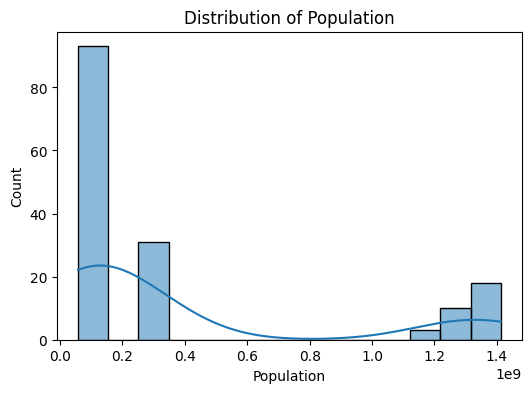

In [ ]:
targets = ["Population"]

for col in targets:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()

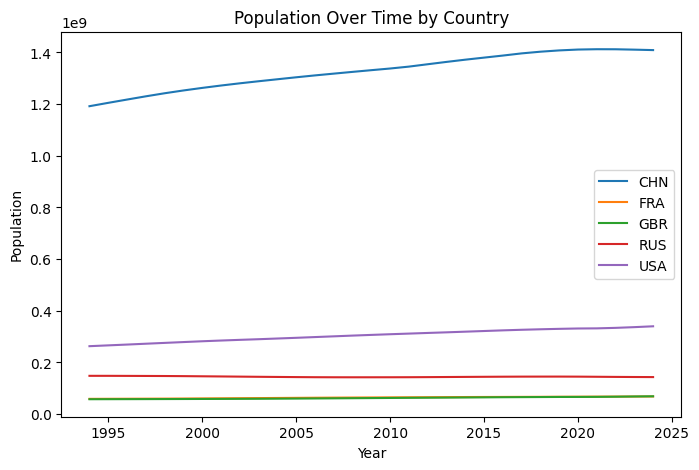

In [ ]:
for col in targets:
    plt.figure(figsize=(8,5))
    for country in df["Country"].unique():
        subset = df[df["Country"] == country]
        plt.plot(subset["Year"], subset[col], label=country)
    plt.title(f"{col} Over Time by Country")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.legend()
    plt.show()


In [ ]:
empty_cols = [col for col in df.columns if df[col].isnull().sum() == df.shape[0]]
df = df.drop(columns=empty_cols)

In [ ]:
df

,Country,Year,D_Expenditure_GDP,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),Refugees,Asylum Seekers,Total number of deaths,Population,GDP_Growth_Annual,GDP_PerCapita_Growth_Annual,GDP_Current_USDollars,Inflation_Annual,Unemployment_Total_of_TLF,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF
0,CHN,1994,1.693480,NaN,1.985710,2.56,113908,0,0,1191835000,13.072710,11.801890,5.670000e+11,24.256990,2.900,3.216,2.522
1,CHN,1995,1.686234,NaN,1.841920,2.79,104691,0,0,1204855000,11.032810,9.832961,7.380000e+11,16.791230,3.000,3.326,2.609
2,CHN,1996,1.652727,NaN,1.853390,2.74,105806,0,0,1217550000,9.976200,8.829514,8.690000e+11,8.313160,3.120,3.459,2.713
3,CHN,1997,1.632651,NaN,NaN,2.79,106731,0,4,1230075000,9.287647,8.174846,9.680000e+11,2.786465,3.230,3.581,2.808
4,CHN,1998,1.655081,NaN,1.844330,2.84,109396,0,0,1241935000,7.920792,6.890190,1.040000e+12,-0.773190,3.240,3.592,2.817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,USA,2020,3.650514,18.813253,5.395320,13.46,349,2491,0,331577720,-2.163030,-2.561810,2.140000e+13,1.233584,8.055,7.807,8.356
151,USA,2021,3.417094,17.506386,5.420380,14.31,426,1662,0,332099760,6.055053,5.888341,2.370000e+13,4.697859,5.349,5.463,5.210
152,USA,2022,3.343259,16.496140,5.382429,14.33,1327,2115,0,334017321,2.512375,1.923862,2.600000e+13,8.002800,3.650,3.680,3.613
153,USA,2023,3.361836,NaN,NaN,13.90,1229,2051,0,336806231,2.887556,2.035600,2.770000e+13,4.116338,3.638,3.795,3.450


In [ ]:
!pip install pmdarima

import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')

df.sort_values(['Country', 'Year'], inplace=True)


In [ ]:
TARGET = 'Population'

EXOG_COLS = [
    'D_Expenditure_GDP',
    'Conflict_Intensity',
    'Health_Expenditure_(% of GDP)',
    'Education_Expenditure_(% of GDP)',
    'Environmental impact (CO2e/capita)',
    'PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)',
    'GDP_Growth_Annual',
    'GDP_PerCapita_Growth_Annual',
    'Inflation_Annual',
    'Unemployment_Total_of_TLF'
]



PROCESSING: CHN
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=56.299, Time=0.08 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.325, Time=0.05 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=50.060, Time=0.22 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=59.004, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=51.081, Time=0.57 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.08 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=50.236, Time=0.06 sec

Best model:  ARIMA(0,2,1)(0,0,0)[0] intercept
Total fit time: 2.554 seconds
Best ARIMA model: (0, 2, 1)

 PERFORMANCE METRICS:
   R² Score: -88.0977
   MAE: 9,552,250 people
   RMSE: 11,486,699 people
   MAPE: 0.68%
   sMAPE: 0.67%
   Avg % Error: 0.68%


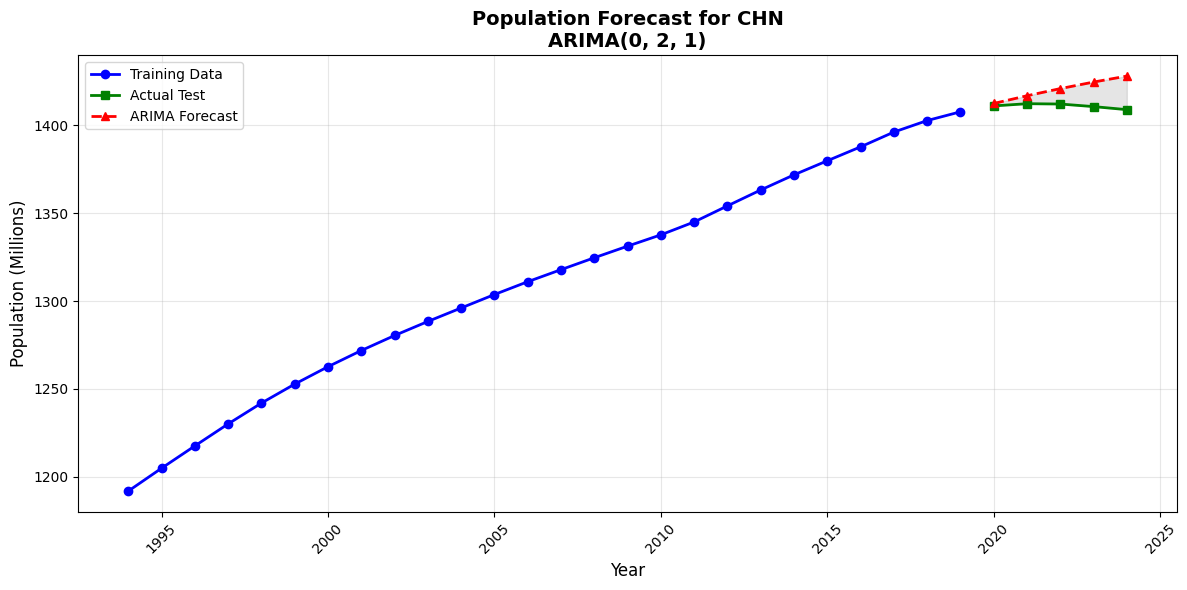


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=1,411,100,000, Predicted=1,412,481,482, Error=-0.10%
   2021: Actual=1,412,360,000, Predicted=1,416,883,415, Error=-0.32%
   2022: Actual=1,412,175,000, Predicted=1,420,950,799, Error=-0.62%
   2023: Actual=1,410,710,000, Predicted=1,424,683,634, Error=-0.99%
   2024: Actual=1,408,975,000, Predicted=1,428,081,920, Error=-1.36%

PROCESSING: FRA
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-43.108, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-82.897, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=18.386, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-92.927, Time=0.31 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-95.093, Time=1.40 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-99.854, Time=1.12 sec
 ARIMA(5,1,0)(0,0,0)[0] int

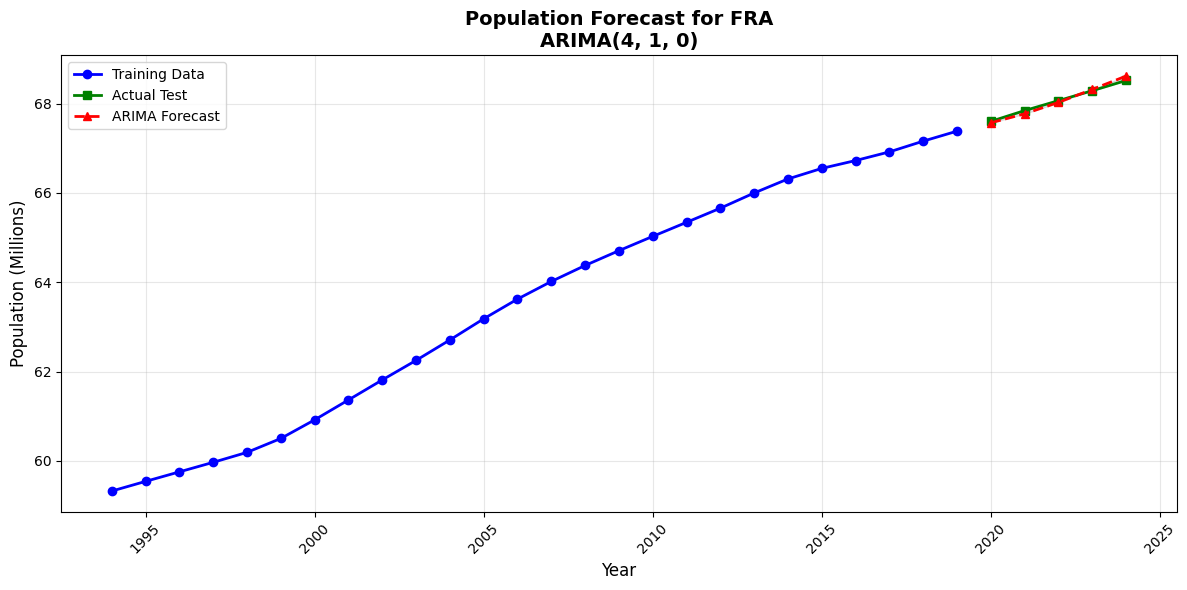


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=67,601,110, Predicted=67,569,170, Error=+0.05%
   2021: Actual=67,842,811, Predicted=67,770,711, Error=+0.11%
   2022: Actual=68,065,015, Predicted=68,025,747, Error=+0.06%
   2023: Actual=68,287,487, Predicted=68,317,230, Error=-0.04%
   2024: Actual=68,516,699, Predicted=68,615,107, Error=-0.14%

PROCESSING: GBR
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-76.837, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-75.125, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-75.081, Time=0.07 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-78.113, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-73.268, Time=0.17 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.339 seconds
Best ARIMA model: (0, 2, 0)

 PERFORMANCE METRICS:
   R² Score: 0.7250
   MAE: 398,200 people
   RMSE: 48

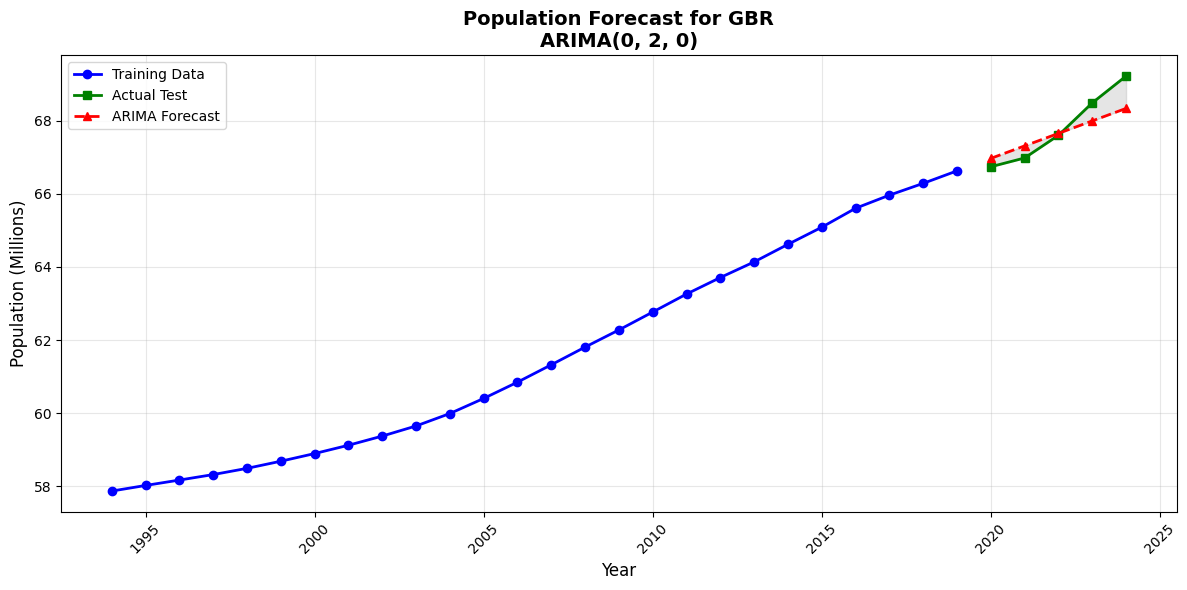


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=66,744,000, Predicted=66,973,000, Error=-0.34%
   2021: Actual=66,984,000, Predicted=67,315,000, Error=-0.49%
   2022: Actual=67,604,000, Predicted=67,657,000, Error=-0.08%
   2023: Actual=68,492,000, Predicted=67,999,000, Error=+0.72%
   2024: Actual=69,226,000, Predicted=68,341,000, Error=+1.28%

PROCESSING: RUS
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-32.147, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-42.614, Time=0.07 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-47.158, Time=0.14 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-34.122, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-46.628, Time=0.15 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=-46.562, Time=0.08 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=-45.498, Time=0.19 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=-49.159, T

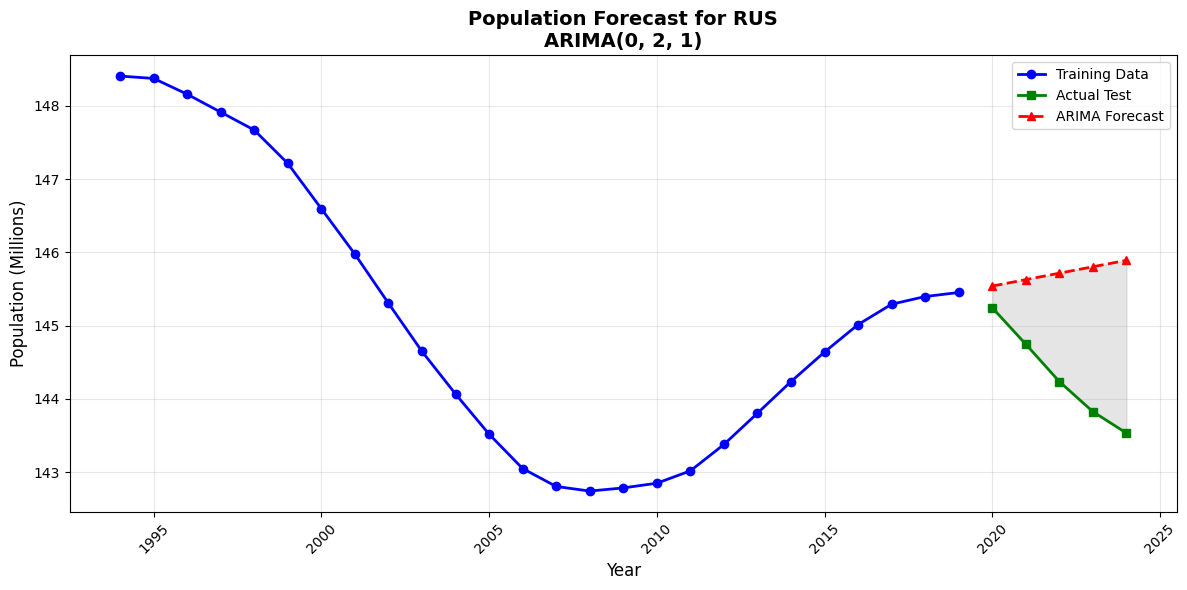


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=145,245,148, Predicted=145,541,180, Error=-0.20%
   2021: Actual=144,746,762, Predicted=145,629,068, Error=-0.61%
   2022: Actual=144,236,933, Predicted=145,716,957, Error=-1.03%
   2023: Actual=143,826,130, Predicted=145,804,846, Error=-1.38%
   2024: Actual=143,533,851, Predicted=145,892,735, Error=-1.64%

PROCESSING: USA
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-20.616, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-20.677, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-19.924, Time=0.04 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-18.742, Time=0.05 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=-19.569, Time=0.05 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-18.831, Time=0.08 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=-20.688, Time=0.14 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=

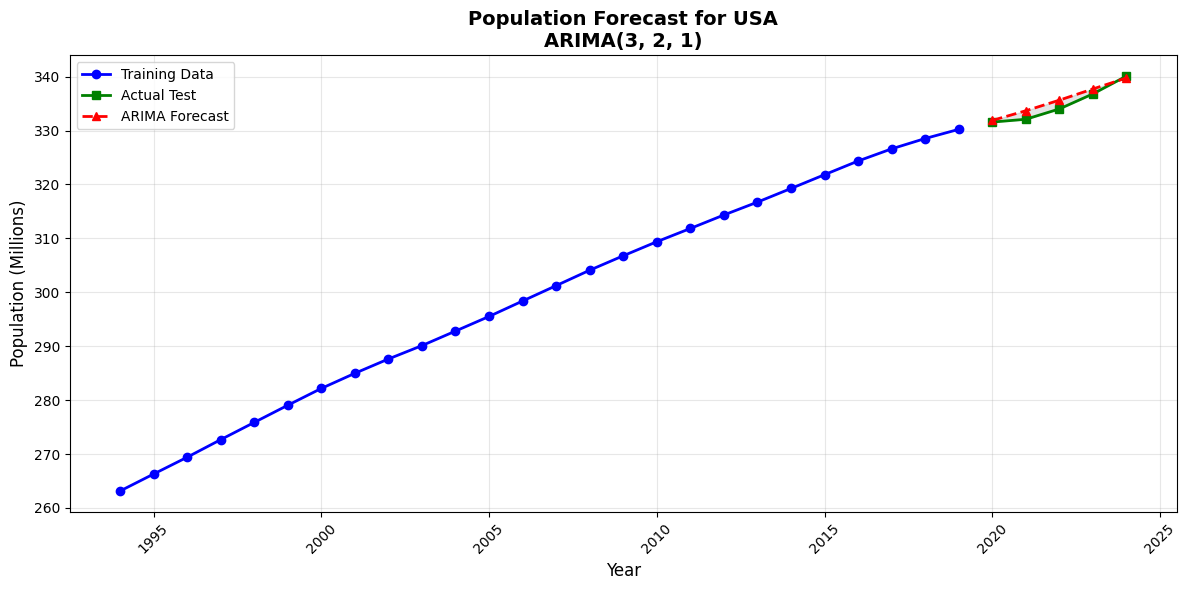


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=331,577,720, Predicted=331,888,629, Error=-0.09%
   2021: Actual=332,099,760, Predicted=333,676,971, Error=-0.47%
   2022: Actual=334,017,321, Predicted=335,645,062, Error=-0.49%
   2023: Actual=336,806,231, Predicted=337,721,470, Error=-0.27%
   2024: Actual=340,110,988, Predicted=339,761,427, Error=+0.10%

 OVERALL PERFORMANCE SUMMARY

Total countries analyzed: 5

Average Metrics Across All Countries:
  Average R² Score: -18.2210
  Average MAE: 2,472,013 people
  Average RMSE: 2,946,346 people
  Average MAPE: 0.52%
  Average sMAPE: 0.52%

 TOP 3 PERFORMING COUNTRIES (by R²):
  1. FRA: R²=0.9646, MAPE=0.08%
  2. USA: R²=0.8772, MAPE=0.29%
  3. GBR: R²=0.7250, MAPE=0.58%

 BOTTOM 3 PERFORMING COUNTRIES (by R²):
  3. GBR: R²=0.7250, MAPE=0.58%
  4. RUS: R²=-5.5744, MAPE=0.97%
  5. CHN: R²=-88.0977, MAPE=0.68%

🔧 MOST COMMON ARIMA ORDERS:
  (0, 2, 1): 2 countries
  (4, 1, 0): 1 countries
  (3, 2, 1): 1 countries
  (0, 2, 0): 1 countries


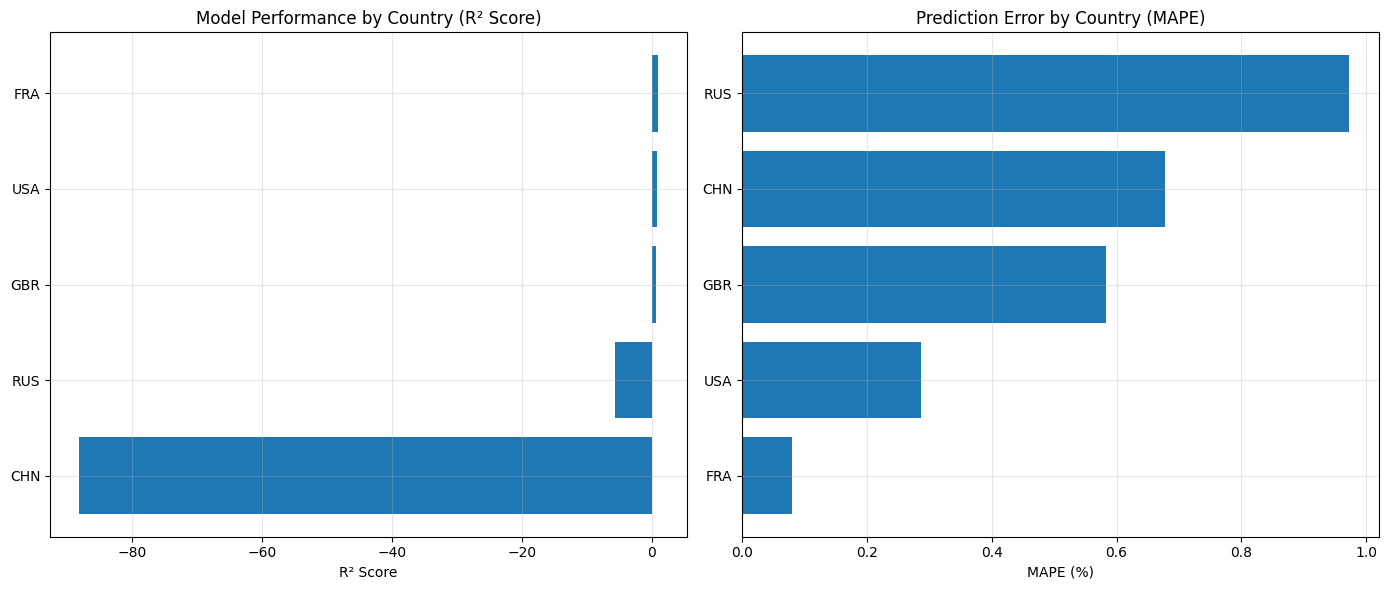


 Metrics and predictions saved to CSV files!
Files created:
   - arima_population_metrics_enhanced.csv
   - arima_population_comparison_enhanced.csv

FUTURE FORECAST EXAMPLE

 FUTURE FORECAST FOR CHN
ARIMA Model: (1, 2, 0)
  2025: 1,406,877,680 (Δ -0.15%)
  2026: 1,404,364,405 (Δ -0.18%)
  2027: 1,401,404,016 (Δ -0.21%)
  2028: 1,397,978,410 (Δ -0.24%)
  2029: 1,394,077,069 (Δ -0.28%)

SAVING ARIMA MODELS TO .h5 FORMAT
ARIMA models saved to: arima_population_model.h5
   File size: 32.38 KB
   Countries saved: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

SAVING COMPLETE!

 File saved at: /content/arima_population_model.h5



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 TO VIEW THE H5 FILE CONTENTS:
   import h5py
   with h5py.File('arima_population_model.h5', 'r') as f:
       print('Model type:', f.attrs['model_type'])
       print('Countries:', list(f['models'].keys()))
       for country in f['models'].keys():
           print(f"{country}: {f['models'][country].attrs['order']}")


In [ ]:
!pip install pmdarima

import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
import h5py
import os
from datetime import datetime
warnings.filterwarnings('ignore')

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')
df.sort_values(['Country', 'Year'], inplace=True)
countries = df['Country'].unique()
test_years = [2020, 2021, 2022, 2023, 2024]

all_metrics = []
all_comparison = []
all_models = {}  # Store models for each country

# ==========================
# FUNCTION: sMAPE
# ==========================
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10))

# ==========================
# ENHANCED VISUALIZATION FUNCTION
# ==========================
def plot_country_forecast(country, train_years, train_values, test_years, test_values, forecast_values, model_order):
    """Plot training, actual test, and forecasted values"""
    plt.figure(figsize=(12, 6))

    # Plot training data
    plt.plot(train_years, train_values, 'b-', label='Training Data', linewidth=2, marker='o')

    # Plot test actual values
    plt.plot(test_years, test_values, 'g-', label='Actual Test', linewidth=2, marker='s')

    # Plot forecast
    plt.plot(test_years, forecast_values, 'r--', label='ARIMA Forecast', linewidth=2, marker='^')

    # Shade forecast area
    plt.fill_between(test_years, test_values, forecast_values, alpha=0.2, color='gray')

    plt.title(f'Population Forecast for {country}\nARIMA{model_order}', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Population (Millions)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================
# LOOP PER COUNTRY
# ==========================
for country in countries:
    print(f"\n{'='*60}")
    print(f"PROCESSING: {country}")
    print('='*60)

    country_df = df[df['Country'] == country].copy()

    # Display data info
    print(f"Data range: {country_df['Year'].min()} - {country_df['Year'].max()}")
    print(f"Total years: {len(country_df)}")

    # Scale population to millions for ARIMA stability
    country_df['Population_Millions'] = country_df['Population'] / 1_000_000

    # Split train/test
    train_df = country_df[~country_df['Year'].isin(test_years)]
    test_df = country_df[country_df['Year'].isin(test_years)]

    if len(test_df) == 0:
        print(f"No test data for {country} in years {test_years}")
        continue

    if len(train_df) < 10:
        print(f"Insufficient training data for {country} ({len(train_df)} years)")
        continue

    ts_train = train_df['Population_Millions'].values
    ts_test = test_df['Population_Millions'].values
    years_train = train_df['Year'].values
    years_test = test_df['Year'].values

    # Fit ARIMA model with more options
    try:
        print(f"Training ARIMA on {len(ts_train)} years, testing on {len(ts_test)} years...")

        model = auto_arima(
            ts_train,
            start_p=0, start_q=0,
            max_p=5, max_q=5,
            d=None,  # Let auto_arima determine differencing
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=True,  # Show model search process
            n_jobs=-1,   # Use all CPU cores
            random_state=42
        )

        print(f"Best ARIMA model: {model.order}")

        # Store model
        all_models[country] = model

        # Generate forecast
        forecast_scaled = model.predict(n_periods=len(ts_test))

        # Scale back to actual population
        forecast = forecast_scaled * 1_000_000
        actual = ts_test * 1_000_000

        # Calculate metrics
        r2 = r2_score(actual, forecast)
        mae = mean_absolute_error(actual, forecast)
        rmse = np.sqrt(mean_squared_error(actual, forecast))
        smape_val = smape(actual, forecast)
        mape_val = np.mean(np.abs((actual - forecast) / actual)) * 100

        # Calculate percentage errors
        pct_errors = np.abs((actual - forecast) / actual) * 100
        avg_pct_error = np.mean(pct_errors)

        print(f"\n PERFORMANCE METRICS:")
        print(f"   R² Score: {r2:.4f}")
        print(f"   MAE: {mae:,.0f} people")
        print(f"   RMSE: {rmse:,.0f} people")
        print(f"   MAPE: {mape_val:.2f}%")
        print(f"   sMAPE: {smape_val:.2f}%")
        print(f"   Avg % Error: {avg_pct_error:.2f}%")

        # Store metrics
        all_metrics.append({
            'Country': country,
            'Train_Years': f"{years_train[0]}-{years_train[-1]}",
            'Test_Years': f"{years_test[0]}-{years_test[-1]}",
            'Train_Size': len(ts_train),
            'Test_Size': len(ts_test),
            'ARIMA_Order': str(model.order),
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape_val,
            'sMAPE': smape_val,
            'Avg_Pct_Error': avg_pct_error,
            'AIC': model.aic(),
            'BIC': model.bic()
        })

        # Year-by-year comparison
        for y, a, f, pct_err in zip(years_test, actual, forecast, pct_errors):
            all_comparison.append({
                'Country': country,
                'Year': y,
                'Population_Actual': a,
                'Population_Predicted': f,
                'Difference': a - f,
                'Pct_Error': pct_err
            })

        # Plot results
        plot_country_forecast(
            country,
            years_train,
            ts_train,
            years_test,
            ts_test,
            forecast_scaled,
            model.order
        )

        # Print year-by-year performance
        print(f"\n YEAR-BY-YEAR PREDICTIONS:")
        for i, (y, a, f) in enumerate(zip(years_test, actual, forecast)):
            error_pct = ((a - f) / a) * 100
            print(f"   {y}: Actual={a:,.0f}, Predicted={f:,.0f}, Error={error_pct:+.2f}%")

    except Exception as e:
        print(f" Error for {country}: {e}")

# ==========================
# SAVE AND DISPLAY RESULTS
# ==========================
if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    comparison_df = pd.DataFrame(all_comparison)

    # Sort metrics by R² score
    metrics_df = metrics_df.sort_values('R2', ascending=False).reset_index(drop=True)

    # Save results
    metrics_df.to_csv('arima_population_metrics_enhanced.csv', index=False)
    comparison_df.to_csv('arima_population_comparison_enhanced.csv', index=False)

    print("\n" + "="*60)
    print(" OVERALL PERFORMANCE SUMMARY")
    print("="*60)

    # Display summary statistics
    print(f"\nTotal countries analyzed: {len(metrics_df)}")
    print(f"\nAverage Metrics Across All Countries:")
    print(f"  Average R² Score: {metrics_df['R2'].mean():.4f}")
    print(f"  Average MAE: {metrics_df['MAE'].mean():,.0f} people")
    print(f"  Average RMSE: {metrics_df['RMSE'].mean():,.0f} people")
    print(f"  Average MAPE: {metrics_df['MAPE'].mean():.2f}%")
    print(f"  Average sMAPE: {metrics_df['sMAPE'].mean():.2f}%")

    # Display best and worst performing countries
    print(f"\n TOP 3 PERFORMING COUNTRIES (by R²):")
    for i, row in metrics_df.head(3).iterrows():
        print(f"  {i+1}. {row['Country']}: R²={row['R2']:.4f}, MAPE={row['MAPE']:.2f}%")

    print(f"\n BOTTOM 3 PERFORMING COUNTRIES (by R²):")
    for i, row in metrics_df.tail(3).iterrows():
        print(f"  {i+1}. {row['Country']}: R²={row['R2']:.4f}, MAPE={row['MAPE']:.2f}%")

    # Display most common ARIMA orders
    print(f"\n🔧 MOST COMMON ARIMA ORDERS:")
    order_counts = metrics_df['ARIMA_Order'].value_counts()
    for order, count in order_counts.head(5).items():
        print(f"  {order}: {count} countries")

    # Create a summary visualization
    plt.figure(figsize=(14, 6))

    # Subplot 1: R² scores by country
    plt.subplot(1, 2, 1)
    sorted_idx = np.argsort(metrics_df['R2'])
    plt.barh(range(len(metrics_df)), metrics_df['R2'].iloc[sorted_idx])
    plt.yticks(range(len(metrics_df)), metrics_df['Country'].iloc[sorted_idx])
    plt.xlabel('R² Score')
    plt.title('Model Performance by Country (R² Score)')
    plt.grid(True, alpha=0.3)

    # Subplot 2: MAPE by country
    plt.subplot(1, 2, 2)
    sorted_idx_mape = np.argsort(metrics_df['MAPE'])
    plt.barh(range(len(metrics_df)), metrics_df['MAPE'].iloc[sorted_idx_mape])
    plt.yticks(range(len(metrics_df)), metrics_df['Country'].iloc[sorted_idx_mape])
    plt.xlabel('MAPE (%)')
    plt.title('Prediction Error by Country (MAPE)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n Metrics and predictions saved to CSV files!")
    print("Files created:")
    print("   - arima_population_metrics_enhanced.csv")
    print("   - arima_population_comparison_enhanced.csv")

else:
    print("\n No models were successfully trained. Check your data and error messages.")

# ==========================
# BONUS: FUTURE FORECASTING FUNCTION
# ==========================
def forecast_future_population(country_name, forecast_years=5):
    """Forecast population for future years"""
    country_df = df[df['Country'] == country_name].copy()

    if len(country_df) == 0:
        print(f"Country '{country_name}' not found in dataset.")
        return None

    # Scale population
    country_df['Population_Millions'] = country_df['Population'] / 1_000_000
    ts_full = country_df['Population_Millions'].values

    # Train on all available data
    try:
        model = auto_arima(
            ts_full,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True
        )

        print(f"\n FUTURE FORECAST FOR {country_name}")
        print(f"ARIMA Model: {model.order}")

        # Generate future forecast
        future_scaled = model.predict(n_periods=forecast_years)
        future_population = future_scaled * 1_000_000

        # Create forecast dataframe
        last_year = country_df['Year'].max()
        future_years = list(range(last_year + 1, last_year + forecast_years + 1))

        forecast_df = pd.DataFrame({
            'Country': country_name,
            'Year': future_years,
            'Population_Forecast': future_population
        })

        # Calculate growth rates
        last_pop = country_df['Population'].iloc[-1]
        for i in range(len(forecast_df)):
            if i == 0:
                growth_pct = ((forecast_df['Population_Forecast'].iloc[i] - last_pop) / last_pop) * 100
            else:
                growth_pct = ((forecast_df['Population_Forecast'].iloc[i] -
                             forecast_df['Population_Forecast'].iloc[i-1]) /
                            forecast_df['Population_Forecast'].iloc[i-1]) * 100

            print(f"  {forecast_df['Year'].iloc[i]}: {forecast_df['Population_Forecast'].iloc[i]:,.0f} "
                  f"(Δ {growth_pct:+.2f}%)")

        return forecast_df

    except Exception as e:
        print(f"Error forecasting for {country_name}: {e}")
        return None

# Example: Forecast next 5 years for a specific country
if len(countries) > 0:
    print("\n" + "="*60)
    print("FUTURE FORECAST EXAMPLE")
    print("="*60)
    forecast_df = forecast_future_population(countries[0], forecast_years=5)

# ==========================
# ADDED: SAVE ARIMA MODEL TO .h5 FORMAT (ONLY H5, NO PKL)
# ==========================
def save_arima_to_h5(models_dict, metrics_df, filename='arima_population_model.h5'):
    """
    Save ARIMA models to .h5 format only (no pickle)
    """
    print("\n" + "="*60)
    print("SAVING ARIMA MODELS TO .h5 FORMAT")
    print("="*60)

    with h5py.File(filename, 'w') as f:

        # 1. Save metadata
        f.attrs['model_type'] = 'ARIMA Population Predictor'
        f.attrs['n_countries'] = len(models_dict)
        f.attrs['created_date'] = str(datetime.now())
        f.attrs['test_years'] = str(test_years)

        # 2. Save metrics summary
        if metrics_df is not None:
            metrics_group = f.create_group('metrics_summary')
            for col in metrics_df.columns:
                if metrics_df[col].dtype in ['float64', 'int64']:
                    metrics_group.attrs[f'avg_{col}'] = float(metrics_df[col].mean())
                    metrics_group.attrs[f'std_{col}'] = float(metrics_df[col].std())

        # 3. Save each country's model
        models_group = f.create_group('models')

        for country, model in models_dict.items():
            country_group = models_group.create_group(country)

            # Get country metrics
            country_metrics = metrics_df[metrics_df['Country'] == country].iloc[0] if len(metrics_df) > 0 else None

            # Save model parameters
            country_group.attrs['order'] = str(model.order)
            country_group.attrs['aic'] = float(model.aic()) if model.aic() else 0
            country_group.attrs['bic'] = float(model.bic()) if model.bic() else 0

            if country_metrics is not None:
                country_group.attrs['r2'] = float(country_metrics['R2'])
                country_group.attrs['mae'] = float(country_metrics['MAE'])
                country_group.attrs['rmse'] = float(country_metrics['RMSE'])
                country_group.attrs['mape'] = float(country_metrics['MAPE'])
                country_group.attrs['arima_order'] = country_metrics['ARIMA_Order']

            # Save ARIMA model parameters (p,d,q)
            params_group = country_group.create_group('params')
            params_group.attrs['p'] = model.order[0]
            params_group.attrs['d'] = model.order[1]
            params_group.attrs['q'] = model.order[2]

            # Save model coefficients if available
            if hasattr(model, 'arparams_') and model.arparams_ is not None:
                params_group.create_dataset('ar_params', data=model.arparams_)
            if hasattr(model, 'maparams_') and model.maparams_ is not None:
                params_group.create_dataset('ma_params', data=model.maparams_)

            # Save training data info
            train_data = df[df['Country'] == country]['Population'].values
            if len(train_data) > 0:
                data_group = country_group.create_group('training_data')
                data_group.create_dataset('population', data=train_data)
                years_data = df[df['Country'] == country]['Year'].values
                data_group.create_dataset('years', data=years_data)

    file_size = os.path.getsize(filename) / 1024
    print(f"ARIMA models saved to: {filename}")
    print(f"   File size: {file_size:.2f} KB")
    print(f"   Countries saved: {list(models_dict.keys())}")

    return filename

# ==========================
# SAVE THE MODELS (ONLY H5)
# ==========================
if len(all_models) > 0:
    h5_file = save_arima_to_h5(all_models, metrics_df, 'arima_population_model.h5')

    print("\n" + "="*60)
    print("SAVING COMPLETE!")
    print("="*60)
    print(f"\n File saved at: {os.path.abspath('arima_population_model.h5')}")

    # Optional: Download in Colab
    try:
        from google.colab import files
        print("\n Downloading file to your computer...")
        files.download('arima_population_model.h5')
    except:
        pass

    print("\n TO VIEW THE H5 FILE CONTENTS:")
    print("   import h5py")
    print("   with h5py.File('arima_population_model.h5', 'r') as f:")
    print("       print('Model type:', f.attrs['model_type'])")
    print("       print('Countries:', list(f['models'].keys()))")
    print("       for country in f['models'].keys():")
    print("           print(f\"{country}: {f['models'][country].attrs['order']}\")")
else:
    print("\n No models to save!")

## **test**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.0 MB/s eta 0:00:00

PROCESSING: CHN
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=56.299, Time=0.11 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.325, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=50.060, Time=0.29 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=59.004, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=51.081, Time=0.07 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=50.236, Time=0.02 sec

Best model:  ARIMA(0,2,1)(0,0,0)[0] intercept
Total fit time: 1.313 seconds
Best ARIMA model: (0, 2, 1)

 PERFORMANCE METRICS:
   R² Score: -88.0977
   MAE: 9,552,250 people
   RMSE: 11,486,699 people
   MAPE: 0.68%
   sMAPE: 0.67%
   Avg % Error: 0.68%


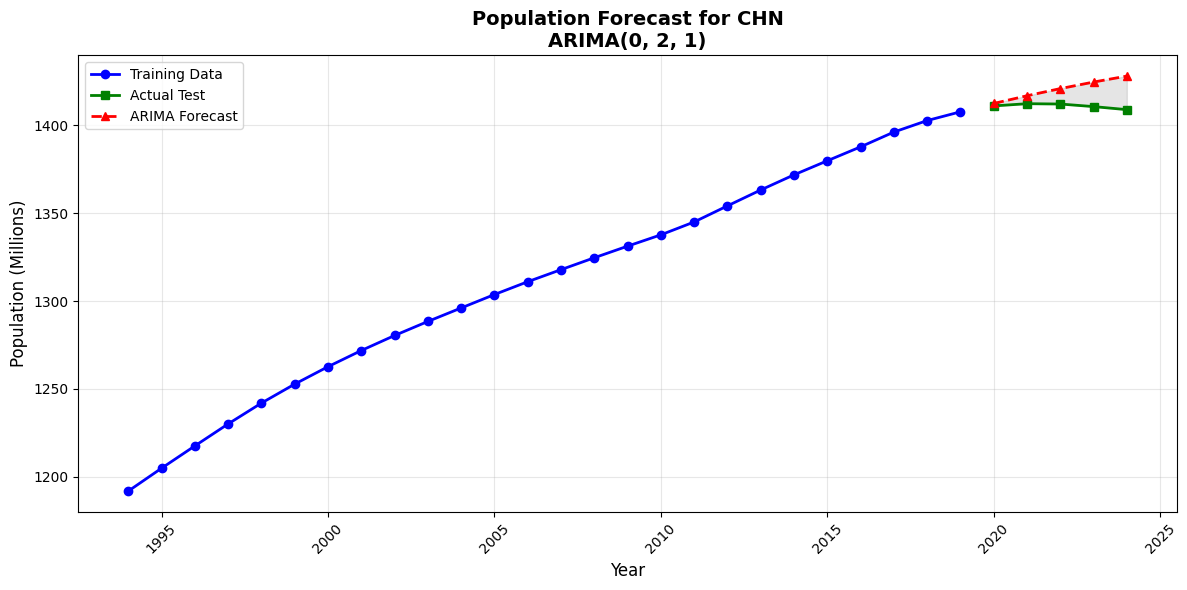


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=1,411,100,000, Predicted=1,412,481,482, Error=-0.10%
   2021: Actual=1,412,360,000, Predicted=1,416,883,415, Error=-0.32%
   2022: Actual=1,412,175,000, Predicted=1,420,950,799, Error=-0.62%
   2023: Actual=1,410,710,000, Predicted=1,424,683,634, Error=-0.99%
   2024: Actual=1,408,975,000, Predicted=1,428,081,920, Error=-1.36%

PROCESSING: FRA
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-43.108, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-82.897, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=18.386, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-92.927, Time=0.09 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-95.093, Time=0.23 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-99.854, Time=0.24 sec
 ARIMA(5,1,0)(0,0,0)[0] int

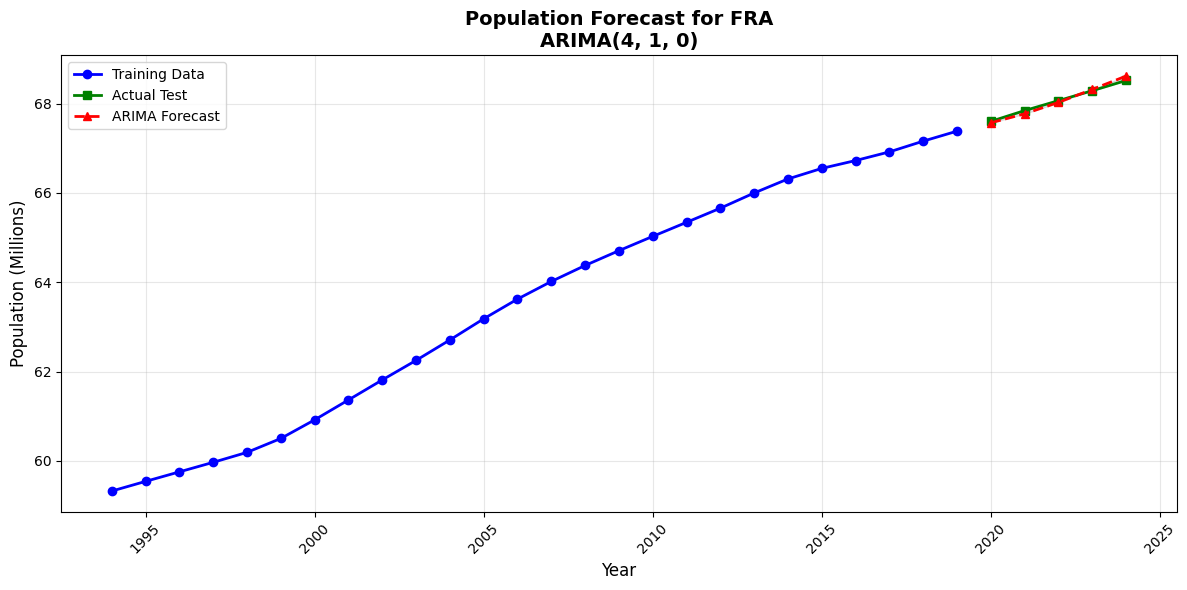


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=67,601,110, Predicted=67,569,170, Error=+0.05%
   2021: Actual=67,842,811, Predicted=67,770,711, Error=+0.11%
   2022: Actual=68,065,015, Predicted=68,025,747, Error=+0.06%
   2023: Actual=68,287,487, Predicted=68,317,230, Error=-0.04%
   2024: Actual=68,516,699, Predicted=68,615,107, Error=-0.14%

PROCESSING: GBR
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-76.837, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-75.125, Time=0.07 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-75.081, Time=0.08 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-78.113, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-73.268, Time=0.21 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.398 seconds
Best ARIMA model: (0, 2, 0)

 PERFORMANCE METRICS:
   R² Score: 0.7250
   MAE: 398,200 people
   RMSE: 48

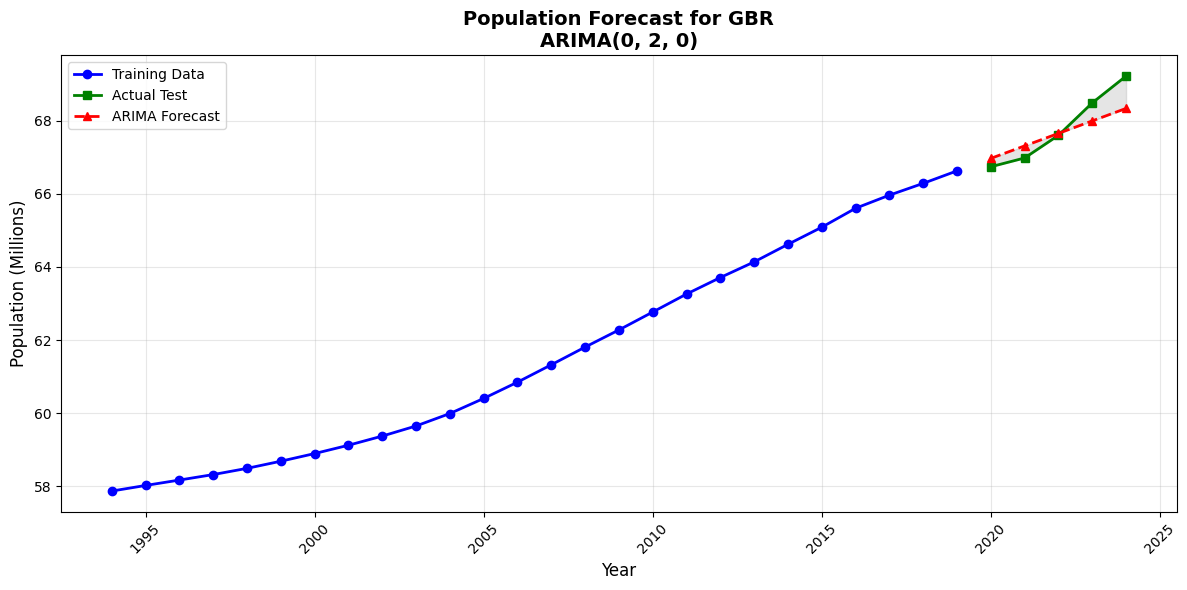


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=66,744,000, Predicted=66,973,000, Error=-0.34%
   2021: Actual=66,984,000, Predicted=67,315,000, Error=-0.49%
   2022: Actual=67,604,000, Predicted=67,657,000, Error=-0.08%
   2023: Actual=68,492,000, Predicted=67,999,000, Error=+0.72%
   2024: Actual=69,226,000, Predicted=68,341,000, Error=+1.28%

PROCESSING: RUS
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-32.147, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-42.614, Time=0.07 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-47.158, Time=0.12 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-34.122, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-46.628, Time=0.15 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=-46.562, Time=0.08 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=-45.498, Time=0.23 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=-49.159, T

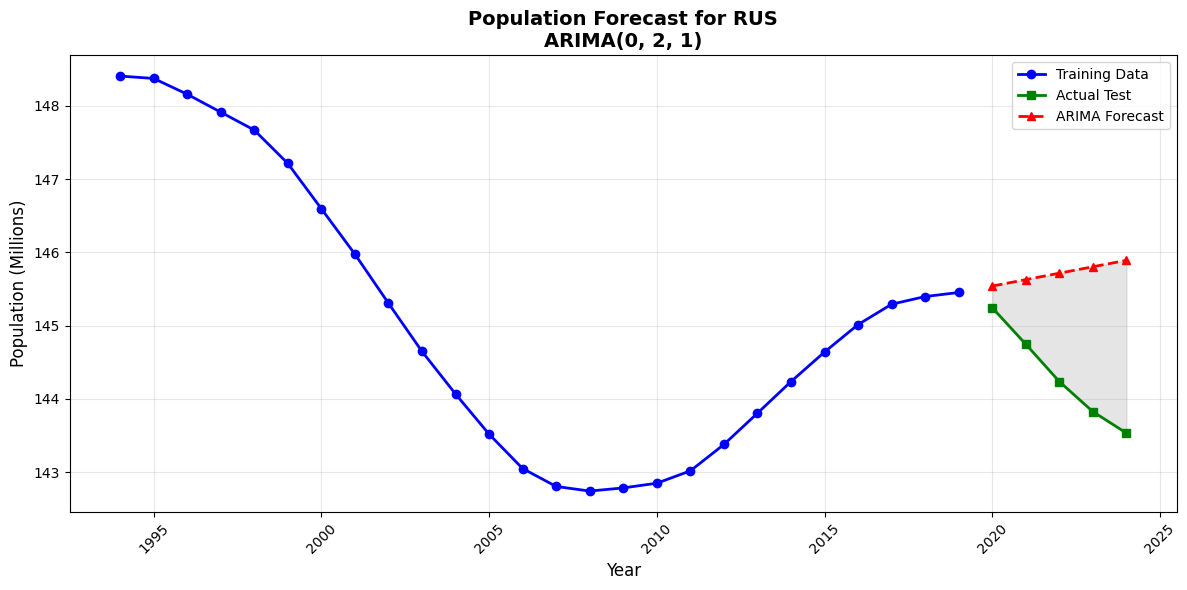


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=145,245,148, Predicted=145,541,180, Error=-0.20%
   2021: Actual=144,746,762, Predicted=145,629,068, Error=-0.61%
   2022: Actual=144,236,933, Predicted=145,716,957, Error=-1.03%
   2023: Actual=143,826,130, Predicted=145,804,846, Error=-1.38%
   2024: Actual=143,533,851, Predicted=145,892,735, Error=-1.64%

PROCESSING: USA
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-20.616, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-20.677, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-19.924, Time=0.04 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-18.742, Time=0.04 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=-19.569, Time=0.09 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-18.831, Time=0.09 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=-20.688, Time=0.12 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=

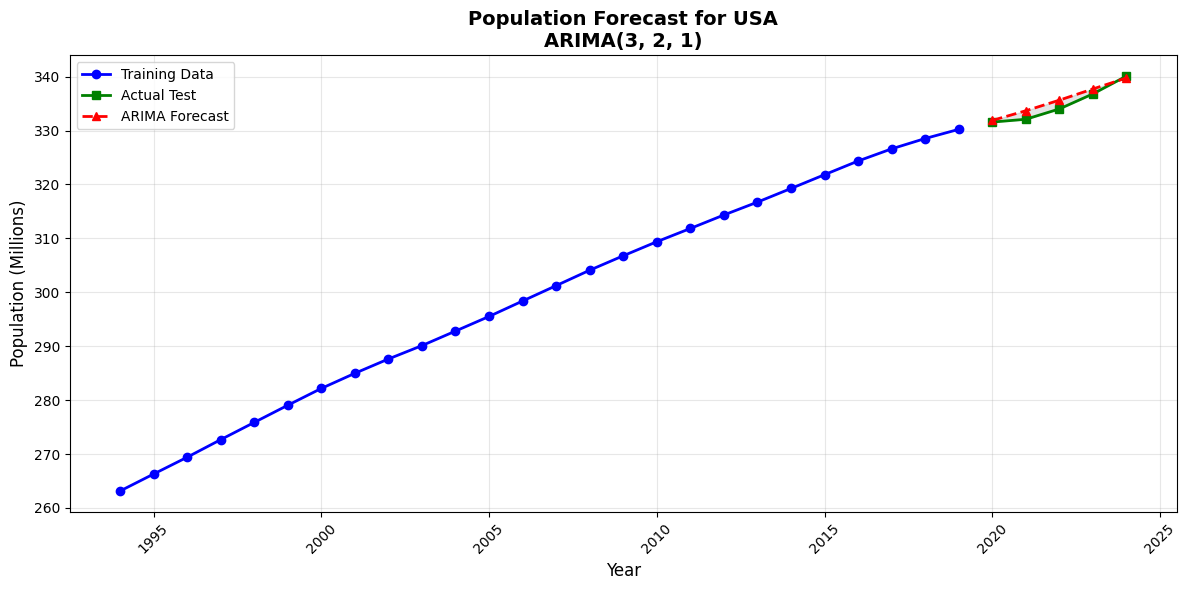


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=331,577,720, Predicted=331,888,629, Error=-0.09%
   2021: Actual=332,099,760, Predicted=333,676,971, Error=-0.47%
   2022: Actual=334,017,321, Predicted=335,645,062, Error=-0.49%
   2023: Actual=336,806,231, Predicted=337,721,470, Error=-0.27%
   2024: Actual=340,110,988, Predicted=339,761,427, Error=+0.10%

 OVERALL PERFORMANCE SUMMARY

Total countries analyzed: 5

Average Metrics Across All Countries:
  Average R² Score: -18.2210
  Average MAE: 2,472,013 people
  Average RMSE: 2,946,346 people
  Average MAPE: 0.52%
  Average sMAPE: 0.52%

 TOP 3 PERFORMING COUNTRIES (by R²):
  1. FRA: R²=0.9646, MAPE=0.08%
  2. USA: R²=0.8772, MAPE=0.29%
  3. GBR: R²=0.7250, MAPE=0.58%

 BOTTOM 3 PERFORMING COUNTRIES (by R²):
  3. GBR: R²=0.7250, MAPE=0.58%
  4. RUS: R²=-5.5744, MAPE=0.97%
  5. CHN: R²=-88.0977, MAPE=0.68%

🔧 MOST COMMON ARIMA ORDERS:
  (0, 2, 1): 2 countries
  (4, 1, 0): 1 countries
  (3, 2, 1): 1 countries
  (0, 2, 0): 1 countries


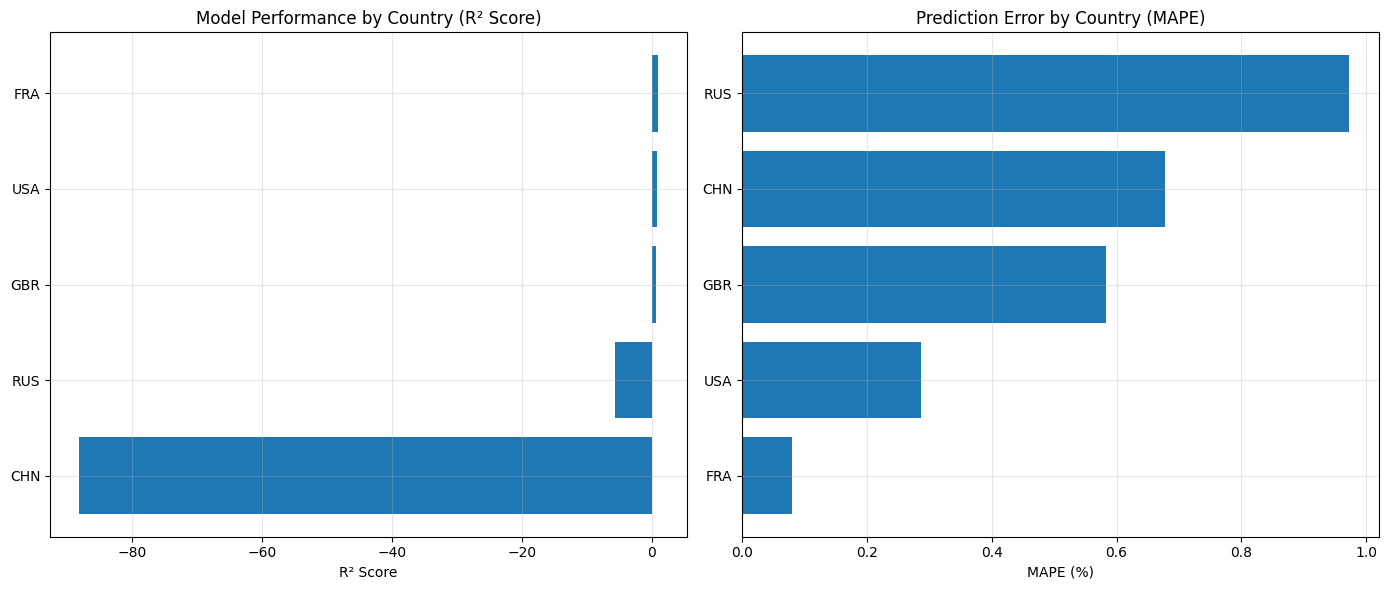


 Metrics and predictions saved to CSV files!
Files created:
   - arima_population_metrics_enhanced.csv
   - arima_population_comparison_enhanced.csv

FUTURE FORECAST EXAMPLE

 FUTURE FORECAST FOR CHN
ARIMA Model: (1, 2, 0)
  2025: 1,406,877,680 (Δ -0.15%)
  2026: 1,404,364,405 (Δ -0.18%)
  2027: 1,401,404,016 (Δ -0.21%)
  2028: 1,397,978,410 (Δ -0.24%)
  2029: 1,394,077,069 (Δ -0.28%)

SAVING ARIMA MODELS TO .h5 FORMAT
ARIMA models saved to: arima_population_model.h5
   File size: 32.38 KB
   Countries saved: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

SAVING ARIMA MODELS TO .pkl FORMAT
ARIMA models saved to: arima_population_model.pkl
File size: 698.23 KB
Countries saved: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

SAVING COMPLETE!

 H5 file saved at: /content/arima_population_model.h5
 PKL file saved at: /content/arima_population_model.pkl



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pmdarima

import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
import h5py
import pickle  # Added for .pkl saving
import os
from datetime import datetime
warnings.filterwarnings('ignore')

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')
df.sort_values(['Country', 'Year'], inplace=True)
countries = df['Country'].unique()
test_years = [2020, 2021, 2022, 2023, 2024]

all_metrics = []
all_comparison = []
all_models = {}  # Store models for each country

# ==========================
# FUNCTION: sMAPE
# ==========================
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10))

# ==========================
# ENHANCED VISUALIZATION FUNCTION
# ==========================
def plot_country_forecast(country, train_years, train_values, test_years, test_values, forecast_values, model_order):
    """Plot training, actual test, and forecasted values"""
    plt.figure(figsize=(12, 6))

    # Plot training data
    plt.plot(train_years, train_values, 'b-', label='Training Data', linewidth=2, marker='o')

    # Plot test actual values
    plt.plot(test_years, test_values, 'g-', label='Actual Test', linewidth=2, marker='s')

    # Plot forecast
    plt.plot(test_years, forecast_values, 'r--', label='ARIMA Forecast', linewidth=2, marker='^')

    # Shade forecast area
    plt.fill_between(test_years, test_values, forecast_values, alpha=0.2, color='gray')

    plt.title(f'Population Forecast for {country}\nARIMA{model_order}', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Population (Millions)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================
# LOOP PER COUNTRY
# ==========================
for country in countries:
    print(f"\n{'='*60}")
    print(f"PROCESSING: {country}")
    print('='*60)

    country_df = df[df['Country'] == country].copy()

    # Display data info
    print(f"Data range: {country_df['Year'].min()} - {country_df['Year'].max()}")
    print(f"Total years: {len(country_df)}")

    # Scale population to millions for ARIMA stability
    country_df['Population_Millions'] = country_df['Population'] / 1_000_000

    # Split train/test
    train_df = country_df[~country_df['Year'].isin(test_years)]
    test_df = country_df[country_df['Year'].isin(test_years)]

    if len(test_df) == 0:
        print(f"No test data for {country} in years {test_years}")
        continue

    if len(train_df) < 10:
        print(f"Insufficient training data for {country} ({len(train_df)} years)")
        continue

    ts_train = train_df['Population_Millions'].values
    ts_test = test_df['Population_Millions'].values
    years_train = train_df['Year'].values
    years_test = test_df['Year'].values

    # Fit ARIMA model with more options
    try:
        print(f"Training ARIMA on {len(ts_train)} years, testing on {len(ts_test)} years...")

        model = auto_arima(
            ts_train,
            start_p=0, start_q=0,
            max_p=5, max_q=5,
            d=None,  # Let auto_arima determine differencing
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=True,  # Show model search process
            n_jobs=-1,   # Use all CPU cores
            random_state=42
        )

        print(f"Best ARIMA model: {model.order}")

        # Store model
        all_models[country] = model

        # Generate forecast
        forecast_scaled = model.predict(n_periods=len(ts_test))

        # Scale back to actual population
        forecast = forecast_scaled * 1_000_000
        actual = ts_test * 1_000_000

        # Calculate metrics
        r2 = r2_score(actual, forecast)
        mae = mean_absolute_error(actual, forecast)
        rmse = np.sqrt(mean_squared_error(actual, forecast))
        smape_val = smape(actual, forecast)
        mape_val = np.mean(np.abs((actual - forecast) / actual)) * 100

        # Calculate percentage errors
        pct_errors = np.abs((actual - forecast) / actual) * 100
        avg_pct_error = np.mean(pct_errors)

        print(f"\n PERFORMANCE METRICS:")
        print(f"   R² Score: {r2:.4f}")
        print(f"   MAE: {mae:,.0f} people")
        print(f"   RMSE: {rmse:,.0f} people")
        print(f"   MAPE: {mape_val:.2f}%")
        print(f"   sMAPE: {smape_val:.2f}%")
        print(f"   Avg % Error: {avg_pct_error:.2f}%")

        # Store metrics
        all_metrics.append({
            'Country': country,
            'Train_Years': f"{years_train[0]}-{years_train[-1]}",
            'Test_Years': f"{years_test[0]}-{years_test[-1]}",
            'Train_Size': len(ts_train),
            'Test_Size': len(ts_test),
            'ARIMA_Order': str(model.order),
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape_val,
            'sMAPE': smape_val,
            'Avg_Pct_Error': avg_pct_error,
            'AIC': model.aic(),
            'BIC': model.bic()
        })

        # Year-by-year comparison
        for y, a, f, pct_err in zip(years_test, actual, forecast, pct_errors):
            all_comparison.append({
                'Country': country,
                'Year': y,
                'Population_Actual': a,
                'Population_Predicted': f,
                'Difference': a - f,
                'Pct_Error': pct_err
            })

        # Plot results
        plot_country_forecast(
            country,
            years_train,
            ts_train,
            years_test,
            ts_test,
            forecast_scaled,
            model.order
        )

        # Print year-by-year performance
        print(f"\n YEAR-BY-YEAR PREDICTIONS:")
        for i, (y, a, f) in enumerate(zip(years_test, actual, forecast)):
            error_pct = ((a - f) / a) * 100
            print(f"   {y}: Actual={a:,.0f}, Predicted={f:,.0f}, Error={error_pct:+.2f}%")

    except Exception as e:
        print(f" Error for {country}: {e}")

# ==========================
# SAVE AND DISPLAY RESULTS
# ==========================
if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    comparison_df = pd.DataFrame(all_comparison)

    # Sort metrics by R² score
    metrics_df = metrics_df.sort_values('R2', ascending=False).reset_index(drop=True)

    # Save results
    metrics_df.to_csv('arima_population_metrics_enhanced.csv', index=False)
    comparison_df.to_csv('arima_population_comparison_enhanced.csv', index=False)

    print("\n" + "="*60)
    print(" OVERALL PERFORMANCE SUMMARY")
    print("="*60)

    # Display summary statistics
    print(f"\nTotal countries analyzed: {len(metrics_df)}")
    print(f"\nAverage Metrics Across All Countries:")
    print(f"  Average R² Score: {metrics_df['R2'].mean():.4f}")
    print(f"  Average MAE: {metrics_df['MAE'].mean():,.0f} people")
    print(f"  Average RMSE: {metrics_df['RMSE'].mean():,.0f} people")
    print(f"  Average MAPE: {metrics_df['MAPE'].mean():.2f}%")
    print(f"  Average sMAPE: {metrics_df['sMAPE'].mean():.2f}%")

    # Display best and worst performing countries
    print(f"\n TOP 3 PERFORMING COUNTRIES (by R²):")
    for i, row in metrics_df.head(3).iterrows():
        print(f"  {i+1}. {row['Country']}: R²={row['R2']:.4f}, MAPE={row['MAPE']:.2f}%")

    print(f"\n BOTTOM 3 PERFORMING COUNTRIES (by R²):")
    for i, row in metrics_df.tail(3).iterrows():
        print(f"  {i+1}. {row['Country']}: R²={row['R2']:.4f}, MAPE={row['MAPE']:.2f}%")

    # Display most common ARIMA orders
    print(f"\n🔧 MOST COMMON ARIMA ORDERS:")
    order_counts = metrics_df['ARIMA_Order'].value_counts()
    for order, count in order_counts.head(5).items():
        print(f"  {order}: {count} countries")

    # Create a summary visualization
    plt.figure(figsize=(14, 6))

    # Subplot 1: R² scores by country
    plt.subplot(1, 2, 1)
    sorted_idx = np.argsort(metrics_df['R2'])
    plt.barh(range(len(metrics_df)), metrics_df['R2'].iloc[sorted_idx])
    plt.yticks(range(len(metrics_df)), metrics_df['Country'].iloc[sorted_idx])
    plt.xlabel('R² Score')
    plt.title('Model Performance by Country (R² Score)')
    plt.grid(True, alpha=0.3)

    # Subplot 2: MAPE by country
    plt.subplot(1, 2, 2)
    sorted_idx_mape = np.argsort(metrics_df['MAPE'])
    plt.barh(range(len(metrics_df)), metrics_df['MAPE'].iloc[sorted_idx_mape])
    plt.yticks(range(len(metrics_df)), metrics_df['Country'].iloc[sorted_idx_mape])
    plt.xlabel('MAPE (%)')
    plt.title('Prediction Error by Country (MAPE)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n Metrics and predictions saved to CSV files!")
    print("Files created:")
    print("   - arima_population_metrics_enhanced.csv")
    print("   - arima_population_comparison_enhanced.csv")

else:
    print("\n No models were successfully trained. Check your data and error messages.")

# ==========================
# BONUS: FUTURE FORECASTING FUNCTION
# ==========================
def forecast_future_population(country_name, forecast_years=5):
    """Forecast population for future years"""
    country_df = df[df['Country'] == country_name].copy()

    if len(country_df) == 0:
        print(f"Country '{country_name}' not found in dataset.")
        return None

    # Scale population
    country_df['Population_Millions'] = country_df['Population'] / 1_000_000
    ts_full = country_df['Population_Millions'].values

    # Train on all available data
    try:
        model = auto_arima(
            ts_full,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True
        )

        print(f"\n FUTURE FORECAST FOR {country_name}")
        print(f"ARIMA Model: {model.order}")

        # Generate future forecast
        future_scaled = model.predict(n_periods=forecast_years)
        future_population = future_scaled * 1_000_000

        # Create forecast dataframe
        last_year = country_df['Year'].max()
        future_years = list(range(last_year + 1, last_year + forecast_years + 1))

        forecast_df = pd.DataFrame({
            'Country': country_name,
            'Year': future_years,
            'Population_Forecast': future_population
        })

        # Calculate growth rates
        last_pop = country_df['Population'].iloc[-1]
        for i in range(len(forecast_df)):
            if i == 0:
                growth_pct = ((forecast_df['Population_Forecast'].iloc[i] - last_pop) / last_pop) * 100
            else:
                growth_pct = ((forecast_df['Population_Forecast'].iloc[i] -
                             forecast_df['Population_Forecast'].iloc[i-1]) /
                            forecast_df['Population_Forecast'].iloc[i-1]) * 100

            print(f"  {forecast_df['Year'].iloc[i]}: {forecast_df['Population_Forecast'].iloc[i]:,.0f} "
                  f"(Δ {growth_pct:+.2f}%)")

        return forecast_df

    except Exception as e:
        print(f"Error forecasting for {country_name}: {e}")
        return None

# Example: Forecast next 5 years for a specific country
if len(countries) > 0:
    print("\n" + "="*60)
    print("FUTURE FORECAST EXAMPLE")
    print("="*60)
    forecast_df = forecast_future_population(countries[0], forecast_years=5)

# ==========================
# SAVE ARIMA MODEL TO .h5 FORMAT
# ==========================
def save_arima_to_h5(models_dict, metrics_df, filename='arima_population_model.h5'):
    """
    Save ARIMA models to .h5 format
    """
    print("\n" + "="*60)
    print("SAVING ARIMA MODELS TO .h5 FORMAT")
    print("="*60)

    with h5py.File(filename, 'w') as f:

        # 1. Save metadata
        f.attrs['model_type'] = 'ARIMA Population Predictor'
        f.attrs['n_countries'] = len(models_dict)
        f.attrs['created_date'] = str(datetime.now())
        f.attrs['test_years'] = str(test_years)

        # 2. Save metrics summary
        if metrics_df is not None:
            metrics_group = f.create_group('metrics_summary')
            for col in metrics_df.columns:
                if metrics_df[col].dtype in ['float64', 'int64']:
                    metrics_group.attrs[f'avg_{col}'] = float(metrics_df[col].mean())
                    metrics_group.attrs[f'std_{col}'] = float(metrics_df[col].std())

        # 3. Save each country's model
        models_group = f.create_group('models')

        for country, model in models_dict.items():
            country_group = models_group.create_group(country)

            # Get country metrics
            country_metrics = metrics_df[metrics_df['Country'] == country].iloc[0] if len(metrics_df) > 0 else None

            # Save model parameters
            country_group.attrs['order'] = str(model.order)
            country_group.attrs['aic'] = float(model.aic()) if model.aic() else 0
            country_group.attrs['bic'] = float(model.bic()) if model.bic() else 0

            if country_metrics is not None:
                country_group.attrs['r2'] = float(country_metrics['R2'])
                country_group.attrs['mae'] = float(country_metrics['MAE'])
                country_group.attrs['rmse'] = float(country_metrics['RMSE'])
                country_group.attrs['mape'] = float(country_metrics['MAPE'])
                country_group.attrs['arima_order'] = country_metrics['ARIMA_Order']

            # Save ARIMA model parameters (p,d,q)
            params_group = country_group.create_group('params')
            params_group.attrs['p'] = model.order[0]
            params_group.attrs['d'] = model.order[1]
            params_group.attrs['q'] = model.order[2]

            # Save model coefficients if available
            if hasattr(model, 'arparams_') and model.arparams_ is not None:
                params_group.create_dataset('ar_params', data=model.arparams_)
            if hasattr(model, 'maparams_') and model.maparams_ is not None:
                params_group.create_dataset('ma_params', data=model.maparams_)

            # Save training data info
            train_data = df[df['Country'] == country]['Population'].values
            if len(train_data) > 0:
                data_group = country_group.create_group('training_data')
                data_group.create_dataset('population', data=train_data)
                years_data = df[df['Country'] == country]['Year'].values
                data_group.create_dataset('years', data=years_data)

    file_size = os.path.getsize(filename) / 1024
    print(f"ARIMA models saved to: {filename}")
    print(f"   File size: {file_size:.2f} KB")
    print(f"   Countries saved: {list(models_dict.keys())}")

    return filename

# ==========================
# NEW: SAVE ARIMA MODEL TO .pkl FORMAT
# ==========================
def save_arima_to_pkl(models_dict, metrics_df, df, filename='arima_population_model.pkl'):
    """
    Save ARIMA models to .pkl format with all data
    """
    print("\n" + "="*60)
    print("SAVING ARIMA MODELS TO .pkl FORMAT")
    print("="*60)

    # Prepare data for saving
    model_data = {
        'models': models_dict,
        'metrics': metrics_df.to_dict() if metrics_df is not None else None,
        'countries': list(models_dict.keys()),
        'test_years': test_years,
        'historical_data': df.copy(),  # Save original data for predictions
        'saved_date': datetime.now(),
        'model_type': 'ARIMA Population Predictor'
    }

    # Save using pickle
    with open(filename, 'wb') as f:
        pickle.dump(model_data, f)

    file_size = os.path.getsize(filename) / 1024
    print(f"ARIMA models saved to: {filename}")
    print(f"File size: {file_size:.2f} KB")
    print(f"Countries saved: {list(models_dict.keys())}")

    return filename

# ==========================
# SAVE THE MODELS (BOTH H5 AND PKL)
# ==========================
if len(all_models) > 0:
    # Save to H5
    h5_file = save_arima_to_h5(all_models, metrics_df, 'arima_population_model.h5')

    # Save to PKL
    pkl_file = save_arima_to_pkl(all_models, metrics_df, df, 'arima_population_model.pkl')

    print("\n" + "="*60)
    print("SAVING COMPLETE!")
    print("="*60)
    print(f"\n H5 file saved at: {os.path.abspath('arima_population_model.h5')}")
    print(f" PKL file saved at: {os.path.abspath('arima_population_model.pkl')}")

    # Optional: Download files in Colab
    try:
        from google.colab import files
        print("\n Downloading files to your computer...")
        files.download('arima_population_model.h5')
        files.download('arima_population_model.pkl')
    except:
        pass
else:
    print("\n No models to save!")

In [ ]:
# ============================================
# POPULATION PREDICTION - LOAD .pkl AND PREDICT (FIXED)
# ============================================

# Step 1: Install required packages (if needed)
!pip install pmdarima

# Step 2: Upload your .pkl file
from google.colab import files
uploaded = files.upload()  # Upload arima_population_model.pkl

# Step 3: Import libraries
import pickle
import pandas as pd
import numpy as np
from pmdarima import auto_arima

# ============================================
# POPULATION PREDICTOR CLASS (FIXED)
# ============================================
class PopulationPredictor:
    """
    Simple class to load ARIMA population model and make predictions
    ONLY NEEDS COUNTRY AND YEAR as input!
    """
    def __init__(self):
        self.models = {}  # country -> ARIMA model
        self.historical_data = None
        self.countries = []
        self.metrics = None
        self.model_type = None
        self.saved_date = None

    def load_from_pkl(self, filename):
        """Load ARIMA models from .pkl file"""
        print(f"Loading population model from {filename}...")

        with open(filename, 'rb') as f:
            data = pickle.load(f)

        self.models = data['models']
        self.countries = data['countries']
        self.historical_data = data['historical_data']
        self.metrics = data['metrics']
        self.model_type = data.get('model_type', 'ARIMA Population Predictor')
        self.saved_date = data.get('saved_date', None)

        print(f" Model loaded successfully!")
        print(f" Model type: {self.model_type}")
        print(f" Countries available: {self.countries}")
        print(f" Saved: {self.saved_date}")

        return self

    def predict_population(self, country, year):
        """
        Predict population for a given country and year
        ONLY NEEDS COUNTRY AND YEAR!
        """
        if country not in self.models:
            print(f" Country '{country}' not found. Available: {self.countries}")
            return None

        # Get historical data for this country
        country_data = self.historical_data[
            self.historical_data['Country'] == country
        ].sort_values('Year')

        if len(country_data) == 0:
            print(f" No historical data for {country}")
            return None

        last_year = country_data['Year'].max()
        last_pop = country_data[country_data['Year'] == last_year]['Population'].values[0]

        print(f"\n Predicting population for {country} - {year}")
        print(f" Last known data: {last_year} → {last_pop:,.0f}")

        # If year is in the past, return actual value
        if year <= last_year:
            if year in country_data['Year'].values:
                actual = country_data[country_data['Year'] == year]['Population'].values[0]
                print(f" Year {year} is in historical data: {actual:,.0f}")
                return actual
            else:
                print(f" Year {year} not in historical data")
                return None

        # For future years, use the ARIMA model
        years_ahead = year - last_year

        # Get the model for this country
        model = self.models[country]

        # Generate forecast
        forecast_scaled = model.predict(n_periods=years_ahead)

        # FIX: Handle if forecast_scaled is an array or single value
        if isinstance(forecast_scaled, np.ndarray):
            if len(forecast_scaled) == 1:
                predicted_millions = forecast_scaled[0]  # Get the single value
            else:
                predicted_millions = forecast_scaled[-1]  # Get the last value
        else:
            predicted_millions = forecast_scaled

        # Convert back to actual population
        predicted_population = predicted_millions * 1_000_000

        # Get the last value in millions for growth calculation
        if 'Population_Millions' in country_data.columns:
            last_pop_millions = country_data['Population_Millions'].iloc[-1]
        else:
            last_pop_millions = last_pop / 1_000_000

        # Calculate growth rate
        growth_rate = ((predicted_millions / last_pop_millions) - 1) * 100

        # FIX: Convert to Python float for formatting
        if isinstance(predicted_population, np.ndarray):
            predicted_population = float(predicted_population)

        print(f" Predicted population: {predicted_population:,.0f}")
        print(f" Growth rate: {growth_rate:+.2f}% over {years_ahead} year(s)")

        return predicted_population

    def get_country_info(self, country):
        """Get information about a country's model"""
        if country not in self.models:
            print(f"Country '{country}' not found")
            return None

        model = self.models[country]

        print(f"\n {country} ARIMA Model Info:")
        print(f"   Order: {model.order}")
        print(f"   AIC: {model.aic():.2f}")
        print(f"   BIC: {model.bic():.2f}")

        # Get historical data
        country_data = self.historical_data[
            self.historical_data['Country'] == country
        ].sort_values('Year')

        if len(country_data) > 0:
            print(f"\n Historical Data:")
            print(f"   Years: {country_data['Year'].min()} - {country_data['Year'].max()}")
            print(f"   Population range: {country_data['Population'].min():,.0f} - {country_data['Population'].max():,.0f}")
            print(f"   Average population: {country_data['Population'].mean():,.0f}")

        return model

# ============================================
# LOAD THE MODEL
# ============================================
print("="*60)
print(" LOADING POPULATION PREDICTION MODEL")
print("="*60)

predictor = PopulationPredictor()
predictor.load_from_pkl('arima_population_model.pkl')

# ============================================
# MAKE PREDICTIONS - ONLY COUNTRY AND YEAR NEEDED!
# ============================================
print("\n" + "="*60)
print(" MAKE POPULATION PREDICTIONS")
print("="*60)
print("\n Usage: predictor.predict_population('COUNTRY', YEAR)")
print(f" Countries available: {predictor.countries}")

# Example predictions
print("\n" + "="*60)
print(" EXAMPLE PREDICTIONS")
print("="*60)

test_countries = ['USA', 'CHN', 'RUS', 'FRA', 'GBR']
for country in test_countries:
    pred = predictor.predict_population(country, 2030)
    if pred:
        print()

# ============================================
# COMPARE DIFFERENT YEARS FOR SAME COUNTRY
# ============================================
print("\n" + "="*60)
print(" POPULATION PROJECTIONS FOR RUSSIA")
print("="*60)

for year in [2025, 2030, 2035, 2040]:
    pred = predictor.predict_population('RUS', year)
    if pred:
        print()

# ============================================
# SIMPLE FUNCTION FOR QUICK PREDICTIONS
# ============================================
def quick_population(country, year):
    """
    Ultra-simple function for quick population predictions
    Usage: quick_population('USA', 2030)
    """
    return predictor.predict_population(country, year)

print("\n" + "="*60)
print(" QUICK PREDICTION FUNCTION READY")
print("="*60)
print("\nUsage: quick_population('USA', 2030)")
print("Example: quick_population('CHN', 2035)")

# Test the quick function
print("\n Quick Predictions:")
print(f"USA 2030: {quick_population('USA', 2030):,.0f}")
print(f"CHN 2035: {quick_population('CHN', 2035):,.0f}")
print(f"RUS 2040: {quick_population('RUS', 2040):,.0f}")

Saving arima_population_model.pkl to arima_population_model (2).pkl
 LOADING POPULATION PREDICTION MODEL
Loading population model from arima_population_model.pkl...
 Model loaded successfully!
 Model type: ARIMA Population Predictor
 Countries available: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']
 Saved: 2026-03-08 12:42:25.898872

 MAKE POPULATION PREDICTIONS

 Usage: predictor.predict_population('COUNTRY', YEAR)
 Countries available: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

 EXAMPLE PREDICTIONS

 Predicting population for USA - 2030
 Last known data: 2024 → 340,110,988
 Predicted population: 341,627,625
 Growth rate: +0.45% over 6 year(s)


 Predicting population for CHN - 2030
 Last known data: 2024 → 1,408,975,000
 Predicted population: 1,431,145,657
 Growth rate: +1.57% over 6 year(s)


 Predicting population for RUS - 2030
 Last known data: 2024 → 143,533,851
 Predicted population: 145,980,623
 Growth rate: +1.70% over 6 year(s)


 Predicting population for FRA - 2030
 Last known data: 2024

# **test**

In [ ]:
!pip install pmdarima

import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
import pickle
import os
from datetime import datetime

warnings.filterwarnings("ignore")

# ==========================
# 1️⃣ LOAD DATA
# ==========================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')
df = df.sort_values(["Country", "Year"])
countries = df["Country"].unique()

# Years to use as test
test_years = [2020, 2021, 2022, 2023, 2024]

# ==========================
# 2️⃣ TRAIN ARIMAX PER COUNTRY
# ==========================
metrics = []
predictions = []
all_models = {}  # store trained models

for country in countries:

    print(f"\nProcessing {country}")

    cdf = df[df["Country"] == country].copy()
    cdf["Population_M"] = cdf["Population"] / 1_000_000  # scale for stability

    train = cdf[~cdf["Year"].isin(test_years)]
    test  = cdf[cdf["Year"].isin(test_years)]

    if len(train) < 10:
        print("Not enough training data")
        continue

    # Target
    y_train = train["Population_M"].values
    y_test  = test["Population_M"].values

    # Exogenous variables
    X_train = train[["D_Expenditure_GDP", "Year"]].values
    X_test  = test[["D_Expenditure_GDP", "Year"]].values

    # Train ARIMAX
    model = auto_arima(y_train,
                       exogenous=X_train,
                       seasonal=False,
                       stepwise=True,
                       suppress_warnings=True)

    print("Best ARIMAX order:", model.order)

    # Store trained model
    all_models[country] = model

    # Predict on test period
    pred_scaled = model.predict(n_periods=len(y_test), exogenous=X_test)
    pred = pred_scaled * 1_000_000
    actual = y_test * 1_000_000

    # Metrics
    mae = mean_absolute_error(actual, pred)
    r2  = r2_score(actual, pred)

    metrics.append({
        "Country": country,
        "ARIMA_Order": model.order,
        "MAE": mae,
        "R2": r2
    })

    # Store yearly predictions
    for y, a, p in zip(test["Year"], actual, pred):
        predictions.append({
            "Country": country,
            "Year": y,
            "Actual_Population": a,
            "Predicted_Population": p
        })

# ==========================
# 3️⃣ SAVE METRICS & PREDICTIONS TO CSV
# ==========================
metrics_df = pd.DataFrame(metrics)
pred_df    = pd.DataFrame(predictions)

metrics_df.to_csv("arimax_metrics.csv", index=False)
pred_df.to_csv("arimax_population_predictions.csv", index=False)

print("\nMetrics & predictions saved to CSV!")

# ==========================
# 4️⃣ RECURSIVE FUTURE FORECAST FUNCTION
# ==========================
def forecast_future(country, future_dex_gdp):
    """
    Recursive multi-step forecast for a country using ARIMAX.
    Inputs:
      country - country name
      future_dex_gdp - list of D_Expenditure_GDP values for future years
    Returns:
      DataFrame with predicted population
    """
    cdf = df[df["Country"] == country].copy()
    cdf["Population_M"] = cdf["Population"] / 1_000_000

    y = cdf["Population_M"].values
    X = cdf[["D_Expenditure_GDP", "Year"]].values

    model = auto_arima(y, exogenous=X, seasonal=False, stepwise=True)

    last_year = cdf["Year"].max()
    future_years = [last_year + i + 1 for i in range(len(future_dex_gdp))]

    future_exog = pd.DataFrame({
        "D_Expenditure_GDP": future_dex_gdp,
        "Year": future_years
    })

    future_pred_scaled = model.predict(n_periods=len(future_exog), exogenous=future_exog.values)
    future_pred = future_pred_scaled * 1_000_000

    return pd.DataFrame({
        "Country": country,
        "Year": future_years,
        "Predicted_Population": future_pred
    })

# ==========================
# 5️⃣ SAVE MODELS + METRICS + DATA TO .PKL
# ==========================
def save_arimax_to_pkl(models_dict, metrics_df, df, filename='arimax_population_model.pkl'):
    """
    Save trained ARIMAX models, metrics, and dataset to a .pkl file
    """
    print("\nSaving ARIMAX models to .pkl format...")

    model_data = {
        'models': models_dict,  # trained ARIMAX models per country
        'metrics': metrics_df.to_dict(orient='records'),  # metrics as list of dicts
        'countries': list(models_dict.keys()),
        'historical_data': df.copy(),  # full dataset
        'saved_date': datetime.now(),
        'model_type': 'ARIMAX Population Predictor',
        'test_years': test_years
    }

    with open(filename, 'wb') as f:
        pickle.dump(model_data, f)

    file_size = os.path.getsize(filename) / 1024
    print(f"ARIMAX models saved to: {filename} ({file_size:.2f} KB)")
    print(f"Countries saved: {list(models_dict.keys())}")
    print(f"Metrics saved for {len(metrics_df)} countries")

    return filename

# ==========================
# 6️⃣ SAVE ALL TRAINED MODELS + METRICS
# ==========================
pkl_file = save_arimax_to_pkl(all_models, metrics_df, df)


Processing CHN
Best ARIMAX order: (0, 2, 1)

Processing FRA
Best ARIMAX order: (2, 1, 1)

Processing GBR
Best ARIMAX order: (0, 2, 0)

Processing RUS
Best ARIMAX order: (0, 2, 1)

Processing USA
Best ARIMAX order: (3, 2, 1)

Metrics & predictions saved to CSV!

Saving ARIMAX models to .pkl format...
ARIMAX models saved to: arimax_population_model.pkl (616.50 KB)
Countries saved: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']
Metrics saved for 5 countries


In [ ]:
# ============================================
# UPLOAD ARIMAX MODEL AND GENERATE FORECASTS
# ============================================

# Step 1: Install required packages (if needed)
!pip install pmdarima

# Step 2: Import libraries
import pickle
import pandas as pd
import numpy as np
from itertools import product
from google.colab import files
import io

# ============================================
# UPLOAD YOUR .pkl MODEL FILE
# ============================================
print("="*60)
print("📤 UPLOAD YOUR ARIMAX MODEL FILE")
print("="*60)
print("\nPlease select your arimax_population_model.pkl file...")

uploaded = files.upload()  # Opens file dialog

# Get the uploaded filename
filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {filename}")
print(f"📦 File size: {len(uploaded[filename]):,} bytes")

# ============================================
# LOAD THE MODEL
# ============================================
print("\n" + "="*60)
print("📂 LOADING MODEL")
print("="*60)

with open(filename, "rb") as f:
    saved_data = pickle.load(f)

# Display model information
print("\n📊 Model contents:")
if isinstance(saved_data, dict):
    print(f"   Dictionary keys: {list(saved_data.keys())}")

    # Try different possible key names for models
    if 'models' in saved_data:
        all_models = saved_data['models']
    elif 'country_models' in saved_data:
        all_models = saved_data['country_models']
    elif 'arima_models' in saved_data:
        all_models = saved_data['arima_models']
    else:
        # Assume the dictionary itself is the models
        all_models = saved_data

    # Get list of countries
    if isinstance(all_models, dict):
        countries = list(all_models.keys())
        print(f"   ✅ Found models for {len(countries)} countries")
        print(f"   🌍 Countries: {countries}")
    else:
        print(f"   ❌ Unexpected model format: {type(all_models)}")
        raise ValueError("Model file does not contain a dictionary of country models")
else:
    print(f"   ❌ Unexpected file format: {type(saved_data)}")
    raise ValueError("Model file is not a dictionary")

# ============================================
# CONFIGURE FORECAST PARAMETERS
# ============================================
print("\n" + "="*60)
print("⚙️  CONFIGURE FORECAST")
print("="*60)

# Country selection
print(f"\n🌍 Available countries: {countries}")
use_all = input("\nForecast for all countries? (y/n): ").strip().lower()

if use_all == 'y':
    selected_countries = countries
else:
    countries_input = input("Enter country codes separated by commas: ").strip().upper()
    selected_countries = [c.strip() for c in countries_input.split(',')]

    # Validate
    valid = [c for c in selected_countries if c in countries]
    invalid = [c for c in selected_countries if c not in countries]

    if invalid:
        print(f"⚠️  Invalid countries ignored: {invalid}")

    if not valid:
        print("❌ No valid countries selected!")
        selected_countries = countries
        print(f"👉 Using all countries instead: {countries}")
    else:
        selected_countries = valid

# Year range
print("\n📅 Forecast period")
start_year = input("Start year (default 2025): ").strip()
end_year = input("End year (default 2030): ").strip()

start_year = int(start_year) if start_year else 2025
end_year = int(end_year) if end_year else 2030
years = list(range(start_year, end_year + 1))

# GDP scenarios
print("\n💰 GDP expenditure scenarios (%)")
print("   Default: 2.5, 3.0, 4.5, 5.0, 12.0")
custom = input("Use custom values? (y/n): ").strip().lower()

if custom == 'y':
    gdp_input = input("Enter GDP values separated by commas: ").strip()
    gdp_values = [float(g.strip()) for g in gdp_input.split(',')]
else:
    gdp_values = [2.5, 3.0, 4.5, 5.0, 12.0]

print(f"\n✅ Configuration complete!")
print(f"   📊 Countries: {len(selected_countries)}")
print(f"   📅 Years: {years}")
print(f"   💰 GDP scenarios: {gdp_values}")
print(f"   🔢 Total combinations: {len(selected_countries) * len(years) * len(gdp_values):,}")

# ============================================
# GENERATE FORECASTS
# ============================================
print("\n" + "="*60)
print("🔮 GENERATING FORECASTS")
print("="*60)

all_forecasts = []

for country in selected_countries:
    print(f"\n📊 Processing {country}...", end=" ")

    try:
        model = all_models[country]

        # Create all combinations for this country
        combos = list(product(years, gdp_values))
        year_list = [y for y, g in combos]
        gdp_list = [g for y, g in combos]

        # Prepare exogenous variables
        exog = pd.DataFrame({
            "Year": year_list,
            "D_Expenditure_GDP": gdp_list
        })

        # Generate predictions
        pred_scaled = model.predict(n_periods=len(exog), exogenous=exog.values)
        pred_population = pred_scaled * 1_000_000

        # Create DataFrame
        df_forecast = pd.DataFrame({
            "Country": country,
            "Year": year_list,
            "GDP_Expenditure_Pct": gdp_list,
            "Predicted_Population": pred_population
        })

        all_forecasts.append(df_forecast)
        print(f"✅ {len(df_forecast)} forecasts")

    except Exception as e:
        print(f"❌ Error: {str(e)}")

# ============================================
# COMBINE AND DISPLAY RESULTS
# ============================================
if all_forecasts:
    forecast_df = pd.concat(all_forecasts, ignore_index=True)

    print("\n" + "="*60)
    print("📊 FORECAST RESULTS")
    print("="*60)

    print(f"\n✅ Generated {len(forecast_df):,} total forecasts")
    print(f"   🌍 Countries: {forecast_df['Country'].nunique()}")
    print(f"   📅 Years: {forecast_df['Year'].min()} - {forecast_df['Year'].max()}")
    print(f"   💰 GDP scenarios: {sorted(forecast_df['GDP_Expenditure_Pct'].unique())}")

    # Show preview
    print("\n📋 Preview (first 10 rows):")
    print(forecast_df.head(10))

    # Summary statistics
    print("\n📈 Summary by Country:")
    summary = forecast_df.groupby('Country').agg({
        'Predicted_Population': ['min', 'max', 'mean']
    }).round(0)
    print(summary)

    # ============================================
    # DOWNLOAD RESULTS
    # ============================================
    print("\n" + "="*60)
    print("💾 DOWNLOAD RESULTS")
    print("="*60)

    # Save to CSV
    csv_filename = f"population_forecast_{start_year}_{end_year}.csv"
    forecast_df.to_csv(csv_filename, index=False)

    # Download
    files.download(csv_filename)
    print(f"\n✅ File '{csv_filename}' downloaded successfully!")

    # ============================================
    # QUERY SPECIFIC FORECASTS
    # ============================================
    print("\n" + "="*60)
    print("🔍 QUERY FORECASTS")
    print("="*60)

    while True:
        print(f"\nAvailable countries: {selected_countries}")
        query = input("\nEnter country,year,gdp (or 'quit'): ").strip()

        if query.lower() == 'quit':
            break

        try:
            parts = query.split(',')
            if len(parts) == 3:
                q_country = parts[0].strip().upper()
                q_year = int(parts[1].strip())
                q_gdp = float(parts[2].strip())

                result = forecast_df[
                    (forecast_df['Country'] == q_country) &
                    (forecast_df['Year'] == q_year) &
                    (forecast_df['GDP_Expenditure_Pct'] == q_gdp)
                ]

                if len(result) > 0:
                    pop = result['Predicted_Population'].values[0]
                    print(f"\n✅ {q_country} in {q_year} with GDP {q_gdp}%: {pop:,.0f}")
                else:
                    print(f"\n❌ No forecast found for {q_country}, {q_year}, GDP {q_gdp}%")
            else:
                print("❌ Please use format: COUNTRY,YEAR,GDP (e.g., USA,2030,3.0)")
        except Exception as e:
            print(f"❌ Error: {e}")

    print("\n" + "="*60)
    print("✅ PROCESS COMPLETE!")
    print("="*60)

else:
    print("\n❌ No forecasts were generated!")

# ============================================
# SIMPLE FUNCTION FOR QUICK PREDICTIONS
# ============================================
def quick_forecast(country, year, gdp):
    """
    Quick function to get a single forecast
    Usage: quick_forecast('USA', 2030, 3.0)
    """
    try:
        result = forecast_df[
            (forecast_df['Country'] == country.upper()) &
            (forecast_df['Year'] == year) &
            (forecast_df['GDP_Expenditure_Pct'] == gdp)
        ]

        if len(result) > 0:
            pop = result['Predicted_Population'].values[0]
            print(f"{country} in {year} with GDP {gdp}%: {pop:,.0f}")
            return pop
        else:
            print(f"No forecast found")
            return None
    except:
        print("Forecast data not available. Run the full script first.")
        return None

print('\n📝 Quick function ready: quick_forecast("USA", 2030, 3.0)')

📤 UPLOAD YOUR ARIMAX MODEL FILE

Please select your arimax_population_model.pkl file...


Saving arimax_population_model (13).pkl to arimax_population_model (13) (4).pkl

✅ File uploaded: arimax_population_model (13) (4).pkl
📦 File size: 494,490 bytes

📂 LOADING MODEL

📊 Model contents:
   Dictionary keys: ['models', 'countries', 'last_values', 'saved_date', 'model_type']
   ✅ Found models for 5 countries
   🌍 Countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

⚙️  CONFIGURE FORECAST

🌍 Available countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

Forecast for all countries? (y/n): y

📅 Forecast period
Start year (default 2025): 2025
End year (default 2030): 2030

💰 GDP expenditure scenarios (%)
   Default: 2.5, 3.0, 4.5, 5.0, 12.0
Use custom values? (y/n): n

✅ Configuration complete!
   📊 Countries: 5
   📅 Years: [2025, 2026, 2027, 2028, 2029, 2030]
   💰 GDP scenarios: [2.5, 3.0, 4.5, 5.0, 12.0]
   🔢 Total combinations: 150

🔮 GENERATING FORECASTS

📊 Processing CHN... ✅ 30 forecasts

📊 Processing FRA... ✅ 30 forecasts

📊 Processing GBR... ✅ 30 forecasts

📊 Processing RUS... ✅ 30 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ File 'population_forecast_2025_2030.csv' downloaded successfully!

🔍 QUERY FORECASTS

Available countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

Enter country,year,gdp (or 'quit'): quit

✅ PROCESS COMPLETE!

📝 Quick function ready: quick_forecast("USA", 2030, 3.0)


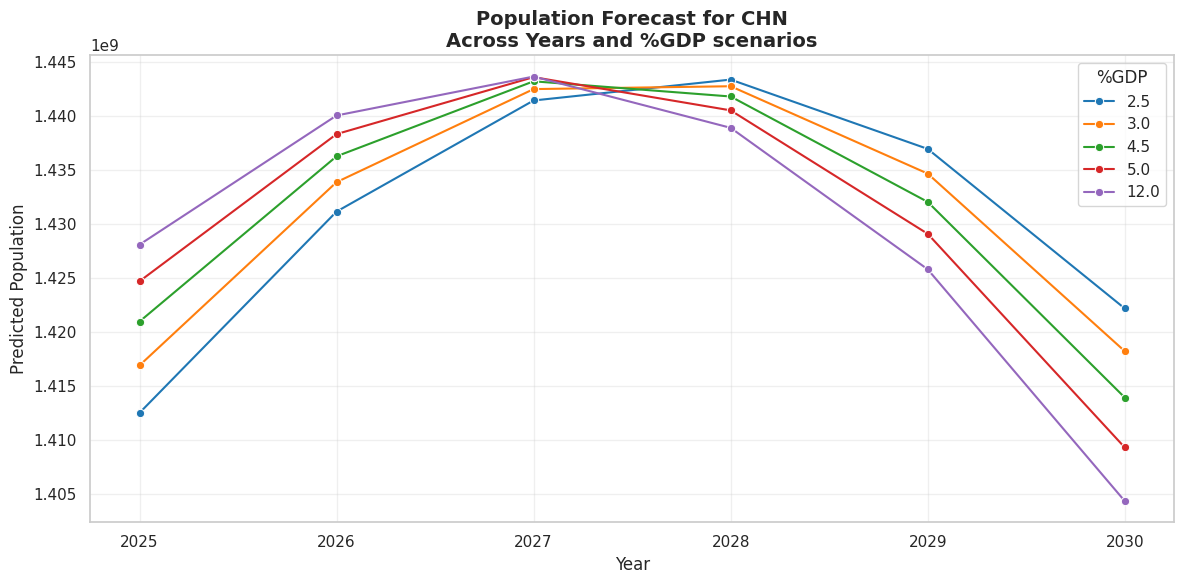

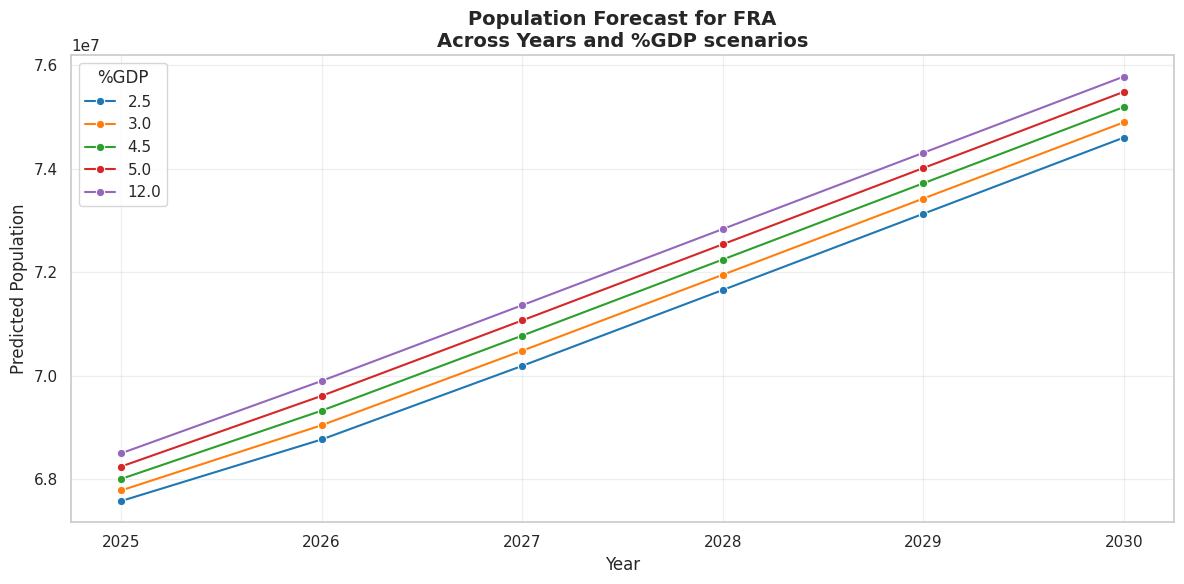

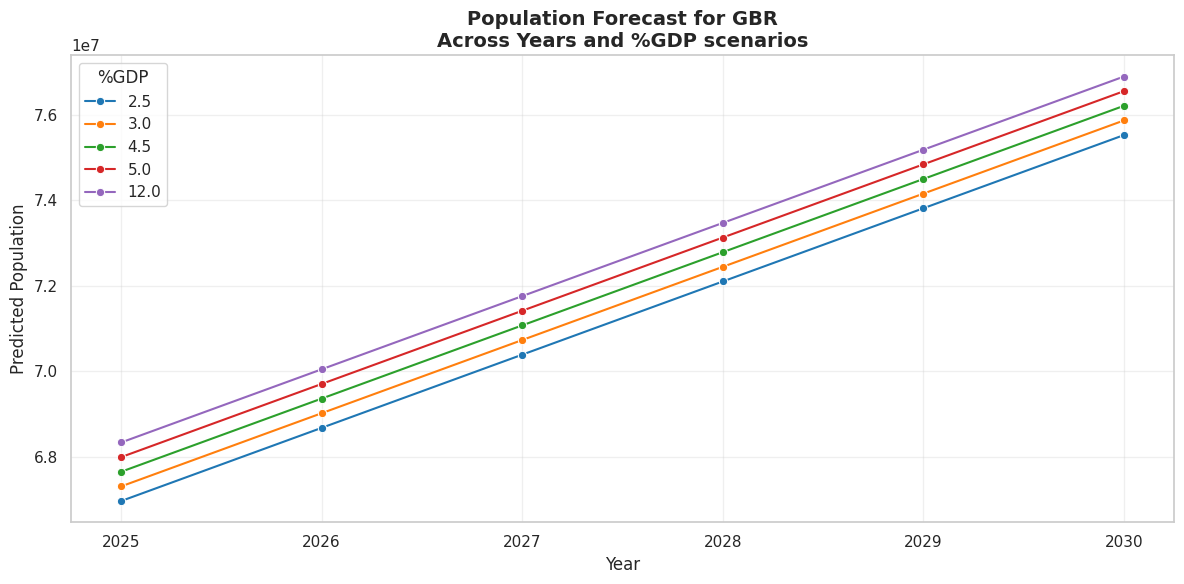

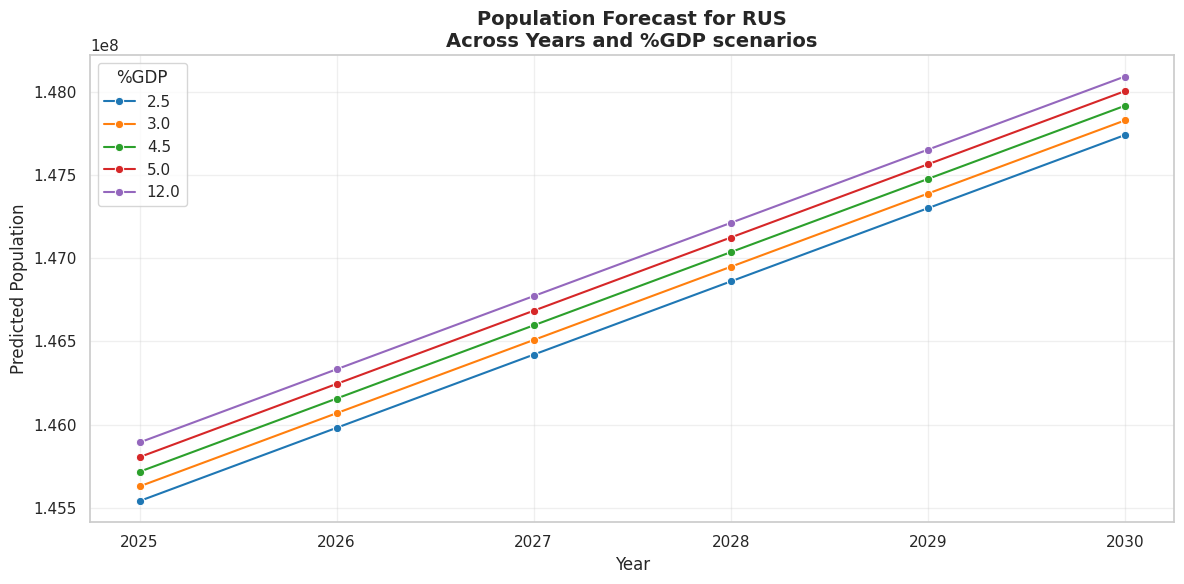

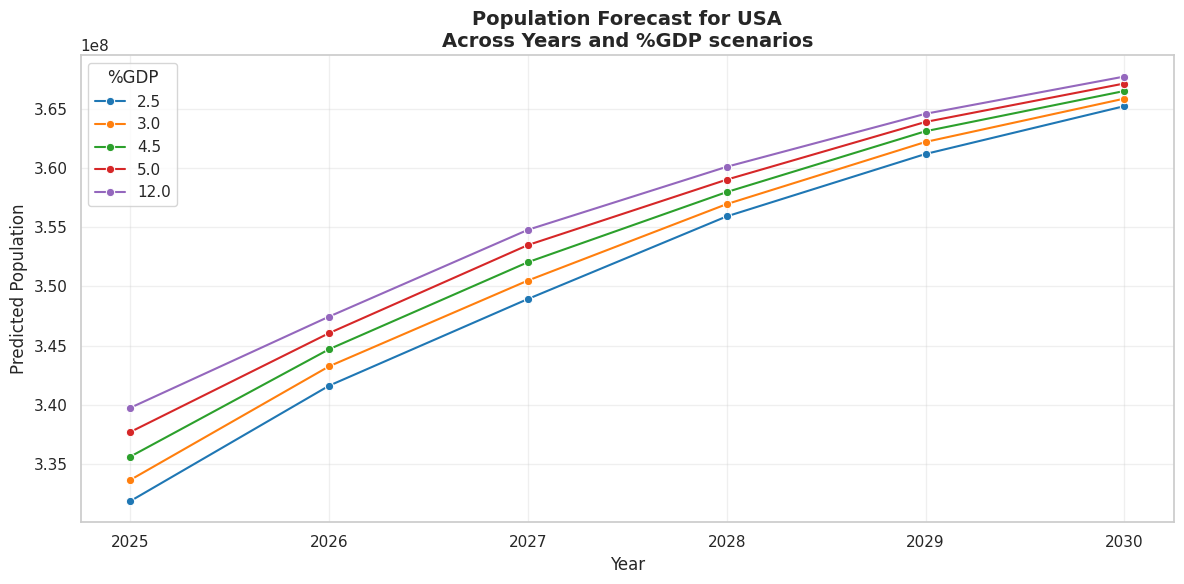

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# 1️⃣ SETUP PLOTTING
# ==========================
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ==========================
# 2️⃣ PLOT FORECASTS FOR EACH COUNTRY
# ==========================
# Example: plot first 5 countries
sample_countries = forecast_df["Country"].unique()[:5]

for country in sample_countries:
    df_country = forecast_df[forecast_df["Country"] == country]

    plt.figure()
    sns.lineplot(
        data=df_country,
        x="Year",
        y="Predicted_Population",
        hue="D_Expenditure_GDP",
        marker="o",
        palette="tab10"
    )
    plt.title(f"Population Forecast for {country}\nAcross Years and %GDP scenarios", fontsize=14, fontweight="bold")
    plt.ylabel("Predicted Population")
    plt.xlabel("Year")
    plt.legend(title="%GDP")
    plt.xticks(df_country["Year"].unique())
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# **testttttttttt**

In [1]:
# ==========================================================
# INSTALL LIBRARY
# ==========================================================
!pip install pmdarima

# ==========================================================
# IMPORTS
# ==========================================================
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import pickle
from datetime import datetime
from google.colab import files
import math

warnings.filterwarnings("ignore")

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')
df = df.sort_values(["Country", "Year"])

countries = df["Country"].unique()

# ==========================================================
# CREATE LAG FEATURES
# ==========================================================
df["Population_M"] = df["Population"] / 1_000_000
df["lag1"] = df.groupby("Country")["Population_M"].shift(1)
df["lag2"] = df.groupby("Country")["Population_M"].shift(2)
df = df.dropna(subset=["lag1", "lag2"])

# ==========================================================
# TEST YEARS
# ==========================================================
test_years = [2020, 2021, 2022, 2023, 2024]

metrics = []
predictions = []
models = {}
last_values = {}

# ==========================================================
# TRAIN MODEL PER COUNTRY
# ==========================================================
for country in countries:

    print(f"\nProcessing {country}")

    cdf = df[df["Country"] == country].copy()

    train = cdf[~cdf["Year"].isin(test_years)]
    test  = cdf[cdf["Year"].isin(test_years)]

    if len(train) < 10:
        print("Not enough training data")
        continue

    if len(test) == 0:
        print("No test data")
        continue

    y_train = train["Population_M"].values
    y_test  = test["Population_M"].values

    X_train = train[["D_Expenditure_GDP", "Year", "lag1", "lag2"]].values
    X_test  = test[["D_Expenditure_GDP", "Year", "lag1", "lag2"]].values

    model = auto_arima(
        y_train,
        exogenous=X_train,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True
    )

    print("Best ARIMA:", model.order)

    models[country] = model

    # =====================================
    # STORE LAST VALUES FOR RECURSIVE PREDICTION
    # =====================================
    last_pop = list(cdf["Population_M"].values[-2:])
    last_year = int(cdf["Year"].max())
    last_defense = float(cdf["D_Expenditure_GDP"].values[-1])

    last_values[country] = {
        "last_population": last_pop,
        "last_year": last_year,
        "last_defense": last_defense
    }

    # =====================================
    # TEST PREDICTION
    # =====================================
    pred_scaled = model.predict(
        n_periods=len(y_test),
        exogenous=X_test
    )

    pred = pred_scaled * 1_000_000
    actual = y_test * 1_000_000

    mae = mean_absolute_error(actual, pred)
    mse = mean_squared_error(actual, pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(actual, pred)

    metrics.append({
        "Country": country,
        "ARIMA_Order": model.order,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

    for y, a, p in zip(test["Year"], actual, pred):
        predictions.append({
            "Country": country,
            "Year": y,
            "Actual_Population": a,
            "Predicted_Population": p
        })

# ==========================================================
# SAVE CSV FILES
# ==========================================================
metrics_df = pd.DataFrame(metrics)
pred_df = pd.DataFrame(predictions)

metrics_df.to_csv("arimax_metrics.csv", index=False)
pred_df.to_csv("arimax_predictions.csv", index=False)

print("CSV files saved")

# ==========================================================
# SAVE MODEL FOR STREAMLIT
# ==========================================================
model_data = {
    "models": models,
    "countries": list(models.keys()),
    "last_values": last_values,
    "saved_date": datetime.now(),
    "model_type": "ARIMAX Population Predictor"
}

filename = "arimax_population_model.pkl"

with open(filename, "wb") as f:
    pickle.dump(model_data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Model saved:", filename)

# ==========================================================
# DOWNLOAD FILES
# ==========================================================
files.download(filename)
files.download("arimax_metrics.csv")
files.download("arimax_predictions.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.0 MB/s eta 0:00:00

Processing CHN
Best ARIMA: (0, 2, 1)

Processing FRA
Best ARIMA: (2, 1, 1)

Processing GBR
Best ARIMA: (0, 2, 0)

Processing RUS
Best ARIMA: (2, 0, 1)

Processing USA
Best ARIMA: (3, 2, 0)
CSV files saved
Model saved: arimax_population_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# UPLOAD ARIMAX MODEL AND GENERATE FORECASTS
# ============================================

# Step 1: Install required packages (if needed)
!pip install pmdarima

# Step 2: Import libraries
import pickle
import pandas as pd
import numpy as np
from itertools import product
from google.colab import files
import io

# ============================================
# UPLOAD YOUR .pkl MODEL FILE
# ============================================
print("="*60)
print("📤 UPLOAD YOUR ARIMAX MODEL FILE")
print("="*60)
print("\nPlease select your arimax_population_model.pkl file...")

uploaded = files.upload()  # Opens file dialog

# Get the uploaded filename
filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {filename}")
print(f"📦 File size: {len(uploaded[filename]):,} bytes")

# ============================================
# LOAD THE MODEL
# ============================================
print("\n" + "="*60)
print("📂 LOADING MODEL")
print("="*60)

with open(filename, "rb") as f:
    saved_data = pickle.load(f)

# Display model information
print("\n📊 Model contents:")
if isinstance(saved_data, dict):
    print(f"   Dictionary keys: {list(saved_data.keys())}")

    # Try different possible key names for models
    if 'models' in saved_data:
        all_models = saved_data['models']
    elif 'country_models' in saved_data:
        all_models = saved_data['country_models']
    elif 'arima_models' in saved_data:
        all_models = saved_data['arima_models']
    else:
        # Assume the dictionary itself is the models
        all_models = saved_data

    # Get list of countries
    if isinstance(all_models, dict):
        countries = list(all_models.keys())
        print(f"   ✅ Found models for {len(countries)} countries")
        print(f"   🌍 Countries: {countries}")
    else:
        print(f"   ❌ Unexpected model format: {type(all_models)}")
        raise ValueError("Model file does not contain a dictionary of country models")
else:
    print(f"   ❌ Unexpected file format: {type(saved_data)}")
    raise ValueError("Model file is not a dictionary")

# ============================================
# CONFIGURE FORECAST PARAMETERS
# ============================================
print("\n" + "="*60)
print("⚙️  CONFIGURE FORECAST")
print("="*60)

# Country selection
print(f"\n🌍 Available countries: {countries}")
use_all = input("\nForecast for all countries? (y/n): ").strip().lower()

if use_all == 'y':
    selected_countries = countries
else:
    countries_input = input("Enter country codes separated by commas: ").strip().upper()
    selected_countries = [c.strip() for c in countries_input.split(',')]

    # Validate
    valid = [c for c in selected_countries if c in countries]
    invalid = [c for c in selected_countries if c not in countries]

    if invalid:
        print(f"⚠️  Invalid countries ignored: {invalid}")

    if not valid:
        print("❌ No valid countries selected!")
        selected_countries = countries
        print(f"👉 Using all countries instead: {countries}")
    else:
        selected_countries = valid

# Year range
print("\n📅 Forecast period")
start_year = input("Start year (default 2025): ").strip()
end_year = input("End year (default 2030): ").strip()

start_year = int(start_year) if start_year else 2025
end_year = int(end_year) if end_year else 2030
years = list(range(start_year, end_year + 1))

# GDP scenarios
print("\n💰 GDP expenditure scenarios (%)")
print("   Default: 2.5, 3.0, 4.5, 5.0, 12.0")
custom = input("Use custom values? (y/n): ").strip().lower()

if custom == 'y':
    gdp_input = input("Enter GDP values separated by commas: ").strip()
    gdp_values = [float(g.strip()) for g in gdp_input.split(',')]
else:
    gdp_values = [2.5, 3.0, 4.5, 5.0, 12.0]

print(f"\n✅ Configuration complete!")
print(f"   📊 Countries: {len(selected_countries)}")
print(f"   📅 Years: {years}")
print(f"   💰 GDP scenarios: {gdp_values}")
print(f"   🔢 Total combinations: {len(selected_countries) * len(years) * len(gdp_values):,}")

# ============================================
# GENERATE FORECASTS
# ============================================
print("\n" + "="*60)
print("🔮 GENERATING FORECASTS")
print("="*60)

all_forecasts = []

for country in selected_countries:
    print(f"\n📊 Processing {country}...", end=" ")

    try:
        model = all_models[country]

        # Create all combinations for this country
        combos = list(product(years, gdp_values))
        year_list = [y for y, g in combos]
        gdp_list = [g for y, g in combos]

        # Prepare exogenous variables
        exog = pd.DataFrame({
            "Year": year_list,
            "D_Expenditure_GDP": gdp_list
        })

        # Generate predictions
        pred_scaled = model.predict(n_periods=len(exog), exogenous=exog.values)
        pred_population = pred_scaled * 1_000_000

        # Create DataFrame
        df_forecast = pd.DataFrame({
            "Country": country,
            "Year": year_list,
            "GDP_Expenditure_Pct": gdp_list,
            "Predicted_Population": pred_population
        })

        all_forecasts.append(df_forecast)
        print(f"✅ {len(df_forecast)} forecasts")

    except Exception as e:
        print(f"❌ Error: {str(e)}")

# ============================================
# COMBINE AND DISPLAY RESULTS
# ============================================
if all_forecasts:
    forecast_df = pd.concat(all_forecasts, ignore_index=True)

    print("\n" + "="*60)
    print("📊 FORECAST RESULTS")
    print("="*60)

    print(f"\n✅ Generated {len(forecast_df):,} total forecasts")
    print(f"   🌍 Countries: {forecast_df['Country'].nunique()}")
    print(f"   📅 Years: {forecast_df['Year'].min()} - {forecast_df['Year'].max()}")
    print(f"   💰 GDP scenarios: {sorted(forecast_df['GDP_Expenditure_Pct'].unique())}")

    # Show preview
    print("\n📋 Preview (first 10 rows):")
    print(forecast_df.head(10))

    # Summary statistics
    print("\n📈 Summary by Country:")
    summary = forecast_df.groupby('Country').agg({
        'Predicted_Population': ['min', 'max', 'mean']
    }).round(0)
    print(summary)

    # ============================================
    # DOWNLOAD RESULTS
    # ============================================
    print("\n" + "="*60)
    print("💾 DOWNLOAD RESULTS")
    print("="*60)

    # Save to CSV
    csv_filename = f"population_forecast_{start_year}_{end_year}.csv"
    forecast_df.to_csv(csv_filename, index=False)

    # Download
    files.download(csv_filename)
    print(f"\n✅ File '{csv_filename}' downloaded successfully!")

    # ============================================
    # QUERY SPECIFIC FORECASTS
    # ============================================
    print("\n" + "="*60)
    print("🔍 QUERY FORECASTS")
    print("="*60)

    while True:
        print(f"\nAvailable countries: {selected_countries}")
        query = input("\nEnter country,year,gdp (or 'quit'): ").strip()

        if query.lower() == 'quit':
            break

        try:
            parts = query.split(',')
            if len(parts) == 3:
                q_country = parts[0].strip().upper()
                q_year = int(parts[1].strip())
                q_gdp = float(parts[2].strip())

                result = forecast_df[
                    (forecast_df['Country'] == q_country) &
                    (forecast_df['Year'] == q_year) &
                    (forecast_df['GDP_Expenditure_Pct'] == q_gdp)
                ]

                if len(result) > 0:
                    pop = result['Predicted_Population'].values[0]
                    print(f"\n✅ {q_country} in {q_year} with GDP {q_gdp}%: {pop:,.0f}")
                else:
                    print(f"\n❌ No forecast found for {q_country}, {q_year}, GDP {q_gdp}%")
            else:
                print("❌ Please use format: COUNTRY,YEAR,GDP (e.g., USA,2030,3.0)")
        except Exception as e:
            print(f"❌ Error: {e}")

    print("\n" + "="*60)
    print("✅ PROCESS COMPLETE!")
    print("="*60)

else:
    print("\n❌ No forecasts were generated!")

# ============================================
# SIMPLE FUNCTION FOR QUICK PREDICTIONS
# ============================================
def quick_forecast(country, year, gdp):
    """
    Quick function to get a single forecast
    Usage: quick_forecast('USA', 2030, 3.0)
    """
    try:
        result = forecast_df[
            (forecast_df['Country'] == country.upper()) &
            (forecast_df['Year'] == year) &
            (forecast_df['GDP_Expenditure_Pct'] == gdp)
        ]

        if len(result) > 0:
            pop = result['Predicted_Population'].values[0]
            print(f"{country} in {year} with GDP {gdp}%: {pop:,.0f}")
            return pop
        else:
            print(f"No forecast found")
            return None
    except:
        print("Forecast data not available. Run the full script first.")
        return None

print('\n📝 Quick function ready: quick_forecast("USA", 2030, 3.0)')

📤 UPLOAD YOUR ARIMAX MODEL FILE

Please select your arimax_population_model.pkl file...


Saving arimax_population_model.pkl to arimax_population_model (1).pkl

✅ File uploaded: arimax_population_model (1).pkl
📦 File size: 494,490 bytes

📂 LOADING MODEL

📊 Model contents:
   Dictionary keys: ['models', 'countries', 'last_values', 'saved_date', 'model_type']
   ✅ Found models for 5 countries
   🌍 Countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

⚙️  CONFIGURE FORECAST

🌍 Available countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

Forecast for all countries? (y/n): Y

📅 Forecast period
Start year (default 2025): 
End year (default 2030): 

💰 GDP expenditure scenarios (%)
   Default: 2.5, 3.0, 4.5, 5.0, 12.0
Use custom values? (y/n): N

✅ Configuration complete!
   📊 Countries: 5
   📅 Years: [2025, 2026, 2027, 2028, 2029, 2030]
   💰 GDP scenarios: [2.5, 3.0, 4.5, 5.0, 12.0]
   🔢 Total combinations: 150

🔮 GENERATING FORECASTS

📊 Processing CHN... ✅ 30 forecasts

📊 Processing FRA... ✅ 30 forecasts

📊 Processing GBR... ✅ 30 forecasts

📊 Processing RUS... ✅ 30 forecasts

📊 Processing

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ File 'population_forecast_2025_2030.csv' downloaded successfully!

🔍 QUERY FORECASTS

Available countries: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

Enter country,year,gdp (or 'quit'): Quit

✅ PROCESS COMPLETE!

📝 Quick function ready: quick_forecast("USA", 2030, 3.0)
